
# Image semantic segmentation
Segmentuje tve kategorie. Sjizdne a nesjizdne.

## Nastaveni
1. tf priklady
2. prepnuti na TF 2.6
3. import knihoven

In [ ]:
#instalace Edge TPU Compileru
! curl https://packages.cloud.google.com/apt/doc/apt-key.gpg | sudo apt-key add -
! echo "deb https://packages.cloud.google.com/apt coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list
! sudo apt-get update
! sudo apt-get install edgetpu-compiler

! pip install -q tensorflow-model-optimization
! pip install "labelbox[data]"
! pip install tf_clahe
! pip install hls4ml


!nvidia-smi -L

import labelbox

from distutils.dir_util import copy_tree
#import tensorflow_model_optimization as tfmot
import random
import tensorflow as tf
import tensorflow_datasets as tfds
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import cv2
import requests
from io import BytesIO
from PIL import Image
#from tensorflow import keras
import tensorflow.keras as keras
import json
#import requests
from io import BytesIO
import os
import os.path
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
from tensorflow.python.framework import constant_op
from tensorflow.python.ops import image_ops
import shutil
import tf_clahe
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder



print(tf.__version__)



  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2659  100  2659    0     0  19361      0 --:--:-- --:--:-- --:--:-- 19408
OK
deb https://packages.cloud.google.com/apt coral-edgetpu-stable main
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Get:2 https://packages.cloud.google.com/apt coral-edgetpu-stable InRelease [6,332 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://packages.cloud.google.com/apt coral-edgetpu-stable/main amd64 Packages [2,317 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,076 kB]
Hit:9 https://ppa.launchpadcontent.net/c2d4u

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:

# konvertuje barevny obrazek na indexy labelu
# idx = {(R, G, B): labelNum}, napr:  {(0, 0, 0): 0, (128, 0, 0): 1}
# pokud neni barva v idx bude pouzita jako labelNum hodnota other
def LabelIndexImage(image, idx, other):
  res = np.zeros((image.shape[0], image.shape[1])).astype(np.uint8)
  res[:]=other
  for c in idx:
    res[(image==c).all(axis=2)] = idx[c]

  return res

# nacitani obrazku z file systemu
# fn - jmeno nacitaneho souboru
# imgDir - adresar s originaly obrazku
# imgExt - extenze obrazku
# gtDir - adresar s obrazky labelu
# gtExt - extenze obrazku labelu
# shape - obrazky budou resamplovany na tento rozmer
# flip - horizontalne
# vraci dvojici - obrazek, label
def load_images(fn, imgDir, imgExt, gtDir, gtExt, shape, flip):
  fnImg=imgDir+fn+imgExt
  fnGt=gtDir+fn+gtExt

  image = tf.io.read_file(fnImg)
  if imgExt=='.bmp':
    image = tf.image.decode_bmp(image)
  else:
    image = tf.image.decode_jpeg(image)
  image = tf.image.convert_image_dtype(image, tf.float32)
  image = tf.image.resize(image, shape, method='area')
  image = tf.slice(image, [0, 0, 0], [shape[0], shape[1], 3])

  gt = tf.io.read_file(fnGt)
  gt = tf.image.decode_png(gt)
  gt = tf.image.resize(gt, shape, method='nearest')

  #if tf.random.uniform(()) > 0.5:
    #image = tf.image.flip_left_right(image)
    #gt = tf.image.flip_left_right(gt)
  if flip:
    return tf.image.flip_left_right(image), tf.image.flip_left_right(gt)
  else:
    return image, gt

# nacitani obrazku z file systemu
# fn - jmeno nacitaneho souboru
# imgDir - adresar s originaly obrazku
# imgExt - extenze obrazku
# gtDir - adresar s obrazky labelu
# gtExt - extenze obrazku labelu
# imgShape - obrazky budou resamplovany na tento rozmer
# gtShape - obrazky labelu budou resamplovany na tento rozmer
# randomize - nahodne poupravi data -
# vraci dvojici - obrazek, label
def load_images2(fn, imgDir, imgExt, gtDir, gtExt, imgShape, gtShape, randomize):
  fnImg=imgDir+fn+imgExt
  fnGt=gtDir+fn+gtExt

  image = tf.io.read_file(fnImg)
  if imgExt=='.bmp':
    image = tf.image.decode_bmp(image)
  else:
    image = tf.image.decode_jpeg(image)
  image = tf.image.convert_image_dtype(image, tf.float32)

  gt = tf.io.read_file(fnGt)
  gt = tf.image.decode_png(gt)

  if randomize:
    rndSize=(1+tf.random.uniform(()))/2
    rndXPos=(1-rndSize)*tf.random.uniform(())
    rndYPos=(1-rndSize)*tf.random.uniform(())
    ish = tf.dtypes.cast(tf.shape(image), tf.float32)
    gsh = tf.dtypes.cast(tf.shape(gt), tf.float32)
    image = tf.image.crop_to_bounding_box(image, tf.dtypes.cast(ish[0]*rndYPos, tf.int32), tf.dtypes.cast(ish[1]*rndXPos, tf.int32), tf.dtypes.cast(ish[0]*rndSize, tf.int32), tf.dtypes.cast(ish[1]*rndSize, tf.int32))
    gt = tf.image.crop_to_bounding_box(gt, tf.dtypes.cast(gsh[0]*rndYPos, tf.int32), tf.dtypes.cast(gsh[1]*rndXPos, tf.int32), tf.dtypes.cast(gsh[0]*rndSize, tf.int32), tf.dtypes.cast(gsh[1]*rndSize, tf.int32))

  # OPRAVA 9. 9. 2026: OBRAZ se zmensoval method='nearest' (starsi load_images pouzival
  # 'area'). Pri 640x480 -> 128x128 zahodi nearest 96 % pixelu a prinese alias; 'area'
  # je prumer bloku, tedy antialiasing. LABEL musi zustat 'nearest' - u indexu tridy
  # by prumerovani vyrobilo neexistujici tridy.
  # ⚠️ NASE PIPELINE JE SCHVALNE SROVNANA S PUVODNIM CHOVANIM (Image.Resize = nejblizsi
  # soused, viz doc/semantic-segmentation.md). Kdyz se model pretrenuje s 'area', musi
  # se PREPNOUT I PIPELINE, jinak model dostane v provozu jinak vzorkovany obraz, nez
  # na jakem se ucil. Je to par "pretrenovat + prepnout", ne samostatna oprava.
  image = tf.image.resize(image, imgShape, method='area')
  image = tf.slice(image, [0, 0, 0], [imgShape[0], imgShape[1], 3])
  gt = tf.image.resize(gt, gtShape, method='nearest')

  if randomize:
    # nahodne stranove prevratit
    if tf.random.uniform(()) > 0.5:
      image = tf.image.flip_left_right(image)
      gt = tf.image.flip_left_right(gt)
    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)
    # Random contast
    # OPRAVA 9. 9. 2026: bylo upper=1, tedy kontrast se JEN SNIZOVAL, nikdy nezvysoval,
    # zatimco saturace (0,8-1,2) i jasnost (+-0,2) jsou symetricke. Vypadalo to na
    # preklep, ne na zamer. ⚠️ Model61.1 v models/ vznikl PRED touto opravou, takze
    # vysledky pretrenovaneho modelu se s nim neporovnavaji 1:1.
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    # Random saturation
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)

    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=(5)/(255), dtype=tf.float32)
    image = image + noise

  #image = tf.image.convert_image_dtype(image*255.0, tf.uint8)
#  image = tf_clahe.clahe(image*255.0, tile_grid_size=(32, 32), clip_limit=0.0)/255.0
# adjust_contrast realizuje clahe
#  image = tf.image.adjust_contrast(image, 1.0)
  image = tf.clip_by_value(image, 0.0, 1.0)
  return image, gt

# nacitani obrazku z file systemu, nijak je neupravuje
# fn - jmeno nacitaneho souboru
# imgDir - adresar s originaly obrazku
# imgExt - extenze obrazku
# gtDir - adresar s obrazky labelu
# gtExt - extenze obrazku labelu
# vraci dvojici - obrazek, label
def load_images3(fn, imgDir, imgExt, gtDir, gtExt):
  fnImg=imgDir+fn+imgExt
  fnGt=gtDir+fn+gtExt

  image = tf.io.read_file(fnImg)
  if imgExt=='.bmp':
    image = tf.image.decode_bmp(image)
  else:
    image = tf.image.decode_jpeg(image)
  image = tf.image.convert_image_dtype(image, tf.float32)

  gt = tf.io.read_file(fnGt)
  gt = tf.image.decode_png(gt)/255
  gt = tf.dtypes.cast(gt, tf.int8)

#  image = tf.slice(image, [0, 0, 0], [imgShape[0], imgShape[1], 3])
  return image, gt

def RandomAugment(image,label):
  if tf.random.uniform(()) > 0.5:
    image = tf.image.flip_left_right(image)
    label = tf.image.flip_left_right(label)
  image = tf.image.random_brightness(image, max_delta=0.2) # Random brightness
  image = tf.image.random_contrast(image, lower=0.8, upper=1) # Random contast
  image = tf.image.random_saturation(image, lower=0.8, upper=1.2) # Random saturation
  return image, label

# vytvoreni datasetu
# fn - seznam jmen barevnych obrazku a gt, vraceno funkci filename
# imgDir - adresar s originaly obrazku
# imgExt - extenze obrazku
# gtDir - adresar s obrazky labelu
# gtExt - extenze obrazku labelu
# shape - rozmery na ktere budou resamplovany obrazky
def datasetFromFilenames(fn, imgDir, imgExt, gtDir, gtExt, shape):
    ds=tf.compat.v2.data.Dataset.from_tensor_slices(fn)
    ds1=ds.map(lambda dp:load_images(dp, imgDir, imgExt, gtDir, gtExt, shape, False) )
#    ds2=ds.map(lambda dp:load_images(dp, imgDir, imgExt, gtDir, gtExt, shape, True) )
#    return ds1.concatenate(ds2)
    return ds1

# vytvoreni datasetu
# fn - seznam jmen barevnych obrazku a gt, vraceno funkci filename
# imgDir - adresar s originaly obrazku
# imgExt - extenze obrazku
# gtDir - adresar s obrazky labelu
# gtExt - extenze obrazku labelu
# imgShape - obrazky budou resamplovany na tento rozmer
# gtShape - obrazky labelu budou resamplovany na tento rozmer
# randomize - nahodne poupravi data -
def datasetFromFilenames2(fn, imgDir, imgExt, gtDir, gtExt, imgShape, gtShape, randomize):
    ds=tf.compat.v2.data.Dataset.from_tensor_slices(fn)
    if randomize:
      ds = ds.repeat(1)

    ds1=ds.map(lambda dp:load_images2(dp, imgDir, imgExt, gtDir, gtExt, imgShape, gtShape, randomize) )
    return ds1

# vytvoreni datasetu, neupravuje obrazky
# fn - seznam jmen barevnych obrazku a gt, vraceno funkci filename
# imgDir - adresar s originaly obrazku
# imgExt - extenze obrazku
# gtDir - adresar s obrazky labelu
# gtExt - extenze obrazku labelu
def datasetFromFilenames3(fn, imgDir, imgExt, gtDir, gtExt):
    ds=tf.compat.v2.data.Dataset.from_tensor_slices(fn)

    ds1=ds.map(lambda dp:load_images3(dp, imgDir, imgExt, gtDir, gtExt) )
    return ds1

def get_flops(model):
  forward_pass = tf.function(
    model.call,
    input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])

  graph_info = profile(forward_pass.get_concrete_function().graph,
                        options=ProfileOptionBuilder.float_operation())

# The //2 is necessary since `profile` counts multiply and accumulate
# as two flops, here we report the total number of multiply accumulate ops
  return graph_info.total_float_ops // 2

def create_mask(pred_mask):
  if pred_mask.shape[-1]!=1:
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask


# stahne obrazky z labelbox.com a zapise je do zadanych adresaru
# uri - uri JSON definice datasetu
# imgDir - adresar s originaly obrazku
# gtDir - adresar s obrazky labelu
# idx = {(R, G, B): labelNum}, napr:  {(0, 0, 0): 0, (128, 0, 0): 1}
# pokud neni barva v idx bude pouzita jako labelNum hodnota other
def DownloadLabelBox(uri, imgDir, gtDir, idx, other):
  response = requests.get(uri)
  datasetJson=response.content

#  print(datasetJson)

  js=json.loads(datasetJson)

  if not os.path.exists(imgDir):
    os.makedirs(imgDir)

  if not os.path.exists(gtDir):
    os.makedirs(gtDir)

  fn=[]
  for a in js:
    fn+=[a['External ID'].split('.')[0]]
    if not os.path.isfile(imgDir+a['External ID']):
      print(a['External ID'])
      response = requests.get(a['Labeled Data'])
      img = Image.open(BytesIO(response.content))
      img.save(imgDir+a['External ID'],'JPEG')

    #print(a['Label']['objects'])
      first=True
      for i in a['Label']['objects']:
        response = requests.get(i['instanceURI'])
        img = Image.open(BytesIO(response.content))
      #print(img.mode)

        if first:
          arr=np.asarray( img, dtype="uint8" )
          res = np.zeros(arr.shape).astype(np.uint8)
          res[...]=arr[...]
          first=False
        else:
          arr=np.asarray( img, dtype="uint8" )
          res[(res[:, :, 3]==0), :]=arr[(res[:, :, 3]==0), :]

      res=LabelIndexImage(res, idx, other)
      img=Image.fromarray(res)
      img.save(gtDir+os.path.splitext(a['External ID'])[0]+'.png','PNG')
  return fn

def DownloadLabelBox2(apiKey, projectID, imgDir, gtDir, idx, other):
  lb = labelbox.Client(api_key=apiKey)
  project = lb.get_project(projectID)
  labels = project.label_generator()

  if not os.path.exists(imgDir):
    os.makedirs(imgDir)

  if not os.path.exists(gtDir):
    os.makedirs(gtDir)

  fn=[]
  for l in labels:
    f=l.uid +'.jpg'
    fn+=[f]
    if not os.path.isfile(imgDir+f):
      print(f)
#      print(l)
      img = Image.fromarray(l.data.value)
      img.save(imgDir+f,'JPEG')

      first=True
      for i in l.annotations:
        if i.name=='Road':
          response = requests.get(i.extra['instanceURI'])
          img = Image.open(BytesIO(response.content))
        #print(img.mode)

          if first:
            arr=np.asarray( img, dtype="uint8" )
            res = np.zeros(arr.shape).astype(np.uint8)
            res[...]=arr[...]
            first=False
          else:
            arr=np.asarray( img, dtype="uint8" )
            res[(res[:, :, 3]==0), :]=arr[(res[:, :, 3]==0), :]

      res=LabelIndexImage(res, idx, other)
      img=Image.fromarray(res)
      img.save(gtDir+os.path.splitext(f)[0]+'.png','PNG')
  return fn

#konverze obrazku MSRC datasetu
# idx - dictionary color:index prevadejici barevny obrazek do indexovaneho gt
# other - hodnota indexu pouzita pokud neni barva v idx
def MSRCConvertGT(fn, idx, other):
  for f in fn:
    r="./MSRC/MSRC_ObjCategImageDatabase_v2/GroundTruth/"+f+"_GT.bmp"
    w="./MSRC/MSRC_ObjCategImageDatabase_v2/GroundTruth/"+f+"_GT.png"
    lbl=Image.open(r)
    lbl=LabelIndexImage(np.asarray( lbl, dtype="uint8" ), idx, other)
    i=Image.fromarray(lbl)
    i.save(w,'PNG')

  return

# zobrazeni obrazku
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'True Mask', 'Predicted Mask', 'Probability ch. 0', 'Probability ch. 1']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    if display_list[i].shape[-1]==1:
      n=display_list[i]
      if isinstance(display_list[i], tf.Tensor):
        n=n.numpy()
      s=n[:, :, 0].shape
      res=np.empty((s[0], s[1], 3), dtype=np.uint8)
      # OPRAVA 9. 9. 2026: byla tu MRTVA VETEV se dvema chybami. isinstance(n.dtype,
      # np.float32) je VZDY False (dtype neni instance np.float32, ma se srovnavat ==),
      # takze se float kanal kreslil vetvi pro 0/1 masku - a kdyby ta podminka nekdy
      # prosla, spadlo by to na builtin min()/max() nad 2D polem ("truth value of an
      # array is ambiguous"). Doplnena i ochrana proti deleni nulou u konstantniho obrazu.
      if n.dtype == np.float32 or n.dtype == np.float64:
        lo = np.min(n[:, :, 0])
        hi = np.max(n[:, :, 0])
        rng = hi - lo if hi > lo else 1.0
        res[:, :, 0]=0
        res[:, :, 1]=((n[:, :, 0]-lo)*255/rng).astype(np.uint8)
        res[:, :, 2]=0
      else:
        res[:, :, 0]=0
        res[:, :, 1]=n[:, :, 0]*255
        res[:, :, 2]=0
      plt.imshow(Image.fromarray(res))

#      plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]*255, scale=False))
    else:
      plt.imshow(display_list[i])
    plt.axis('off')
  plt.show()

# vypocet presnosti modelu
def ModelAccuracy(model, dataset):
  m=tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy', dtype=None)
  for image, mask in dataset:
    if len(image.shape)==3:
      pred_mask = model.predict(image[tf.newaxis, ...])
      if pred_mask.ndim==3:
        pred_mask=tf.concat([(1-pred_mask)[..., tf.newaxis], pred_mask[..., tf.newaxis]], 3)
      m.update_state(mask, pred_mask[0])
    if len(image.shape)==4:
      pred_mask = model.predict(image)
      m.update_state(mask, pred_mask)
  return m.result().numpy()

def SaveFrozenGraph(model, path, suffix=''):
  full_model = tf.function(model).get_concrete_function(tf.TensorSpec(model.inputs[0].shape, model.inputs[0].dtype))

    # Get frozen ConcreteFunction
  frozen_func = convert_variables_to_constants_v2(full_model)
  frozen_func.graph.as_graph_def()

  layers = [op.name for op in frozen_func.graph.get_operations()]
  #print("-" * 50)
  #print("Frozen model layers: ")
  #for layer in layers:
    #print(layer)

  print("-" * 50)
  print("Frozen model inputs: ")
  print(frozen_func.inputs)
  print("Frozen model outputs: ")
  print(frozen_func.outputs)

    # Save frozen graph from frozen ConcreteFunction to hard drive
  tf.io.write_graph(graph_or_graph_def=frozen_func.graph,
                      logdir=path+"/"+model.name+"/",
                      name="frozen"+model.name+suffix+".pb",
                      as_text=False)


def representative_data_gen():
  for ii in trainOrig:
    image = ii[0]
    image = tf.expand_dims(image, 0)
    yield [image]

def SaveTFLite(model, path):
  d=path+"/"+model.name
  if not os.path.exists(d):
    os.makedirs(d)

  # OPRAVA 9. 9. 2026, dve veci naraz:
  #
  # (a) TOHLE NEBYL FLOAT MODEL. Bylo tu cnv.optimizations=[Optimize.DEFAULT] BEZ
  #     representative_dataset, coz je dynamic-range kvantizace: vahy se ulozi jako int8
  #     a pocita se ve floatu. Soubor se pritom jmenoval "<model>.tflite" a vsude se o nem
  #     mluvilo jako o float verzi - takze Model61.1.tflite v ARBot3 NENI float, jak se
  #     dlouho tvrdilo. Optimizations je proto pryc.
  #
  # (b) DYNAMICKE TVARY. from_keras_model(model) bez udani vstupniho tvaru neumoznilo
  #     konvertoru spocitat vnitrni velikosti, takze misto "zvetsi na 8x8" zapsal
  #     "zjisti velikost vstupu, vynasob dvema a zvetsi na to" - retez Shape ->
  #     StridedSlice -> Mul -> ResizeNN, petkrat, a deklarovany vystup [1,1,1,2].
  #     Takovy soubor tf2onnx neprevede. Leci to concrete_function s pevnym TensorSpec.
  #     Viz Src/Colab/ExportFloatModel.ipynb a doc/semantic-segmentation.md.
  spec = tf.TensorSpec((1,) + tuple(model.input_shape[1:]), tf.float32)
  fce = tf.function(lambda x: model(x)).get_concrete_function(spec)
  cnv = tf.lite.TFLiteConverter.from_concrete_functions([fce], model)
  tflmodel=cnv.convert()
  open(d+"/"+model.name+".tflite", "wb").write(tflmodel)

  print('float32 done')

# int8
  converter = tf.lite.TFLiteConverter.from_keras_model(model)
  converter.experimental_new_converter = True
  # This enables quantization
  converter.optimizations = [tf.lite.Optimize.DEFAULT]
  # This sets the representative dataset for quantization
  converter.representative_dataset = representative_data_gen
  # This ensures that if any ops can't be quantized, the converter throws an error
  converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
  # For full integer quantization, though supported types defaults to int8 only, we explicitly declare it for clarity.
  converter.target_spec.supported_types = [tf.int8]
  # These set the input and output tensors to uint8 (added in r2.3)
  converter.inference_input_type = tf.uint8
  converter.inference_output_type = tf.uint8
  tflite_model = converter.convert()

  open(d+"/"+model.name+"_int8.tflite", "wb").write(tflite_model)

  print('int8 done')

# int16
  converter = tf.lite.TFLiteConverter.from_keras_model(model)
  converter.experimental_new_converter = True
  # This enables quantization
  converter.optimizations = [tf.lite.Optimize.DEFAULT]
  # This sets the representative dataset for quantization
  converter.representative_dataset = representative_data_gen
  # This ensures that if any ops can't be quantized, the converter throws an error
  converter.target_spec.supported_ops = [tf.lite.OpsSet.EXPERIMENTAL_TFLITE_BUILTINS_ACTIVATIONS_INT16_WEIGHTS_INT8]
  # For full integer quantization, though supported types defaults to int8 only, we explicitly declare it for clarity.
  converter.target_spec.supported_types = [tf.int16]
  # These set the input and output tensors to uint8 (added in r2.3)
  converter.inference_input_type = tf.int16
  converter.inference_output_type = tf.int16
  tflite_model = converter.convert()

  open(d+"/"+model.name+"_int16.tflite", "wb").write(tflite_model)

  print('int16 done')



  f="edgetpu_compiler -o "+resultDir+"/models/"+model.name+" "+resultDir+"/models/"+model.name+"/"+model.name+"_int8.tflite"
  print(f)
  os.system(f)

def show_predictions(model, dataset, num=1):
  cnt=0;
  for image, mask in dataset.take(num):
    print(cnt)
    cnt=cnt+1;
    if len(image.shape)==3:
      pred_mask = model.predict(image[tf.newaxis, ...])
      if pred_mask.ndim==3:
        pred_mask=pred_mask[...,tf.newaxis]
      if pred_mask.shape[3]==1:
        display([image, mask, create_mask(pred_mask)[0], pred_mask[0][...,0][...,tf.newaxis]])
      else:
        display([image, mask, create_mask(pred_mask)[0], pred_mask[0][...,0][...,tf.newaxis], pred_mask[0][...,1][...,tf.newaxis]])
    else:
      for i in range(image.shape[0]):
        pred_mask = model.predict(image[i][tf.newaxis, ...])
        if pred_mask.ndim==3:
          pred_mask=pred_mask[...,tf.newaxis]
        if pred_mask.shape[3]==1:
          display([image[i],
                  mask[i],
                  create_mask(pred_mask)[0],
                  pred_mask[0][...,0][...,tf.newaxis]])
        else:
          display([image[i],
                  mask[i],
                  create_mask(pred_mask)[0],
                  pred_mask[0][...,0][...,tf.newaxis],
                  pred_mask[0][...,1][...,tf.newaxis]])

def TFLitePredict(model_path, image, verbose=False):
# Load TFLite model and allocate tensors.
  interpreter = tf.lite.Interpreter(model_path=model_path)

# Get input and output tensors.
  input_details = interpreter.get_input_details()
  output_details = interpreter.get_output_details()

# Allocate tensors
  interpreter.allocate_tensors()

# Print the input and output details of the model
  if(verbose):
    print()
    print("Input details:")
    print(input_details)
    print()
    print("Output details:")
    print(output_details)
    print()

# Convert features to NumPy array
  np_features = np.array(image)

# If the expected input type is int8 (quantized model), rescale data
  input_type = input_details[0]['dtype']
  if input_type == np.uint8 or input_type == np.int16:
    input_scale, input_zero_point = input_details[0]['quantization']
    if(verbose):
      print("Input scale:", input_scale)
      print("Input zero point:", input_zero_point)
      print()
    np_features = (np_features / input_scale) + input_zero_point
    np_features = np.around(np_features)

# Convert features to NumPy array of expected type
  np_features = np_features.astype(input_type)

# Add dimension to input sample (TFLite model expects (# samples, data))
  np_features = np.expand_dims(np_features, axis=0)

# Create input tensor out of raw features
  interpreter.set_tensor(input_details[0]['index'], np_features)

# Run inference
  interpreter.invoke()

# output_details[0]['index'] = the index which provides the input
  output = interpreter.get_tensor(output_details[0]['index'])

# If the output type is int8 (quantized model), rescale data
  output_type = output_details[0]['dtype']
  print(output_type)
  if output_type == np.uint8 or output_type == np.int16:
    output_scale, output_zero_point = output_details[0]['quantization']
    if(verbose):
      print("Raw output scores:", output)
      print("Output scale:", output_scale)
      print("Output zero point:", output_zero_point)
      print()
    output = output_scale * (output.astype(np.float32) - output_zero_point)
  return output


class Trainer:
  def __init__(self, models, directory):
    self.history={}
    self.models=models
    self.directory=directory
    #self.checkpoint=tf.train.Checkpoint(v=tf.Variable(1), max_to_keep=10)
    #self.mgr=tf.train.CheckpointManager(self.checkpoint, directory=self.directory+'/train')
    #if(self.mgr.latest_checkpoint!=None):
      #self.checkpoint.restore(self.mngr.latest_checkpoint).assert_consumed()

  def LoadBest(self):
    for m in self.models:
      acc=self.history[m.name]['val_sparse_categorical_accuracy']
      m.load_weights(self.directory+'/'+ m.name+'/'+ m.name+'_weights_'+str(max(acc))+'.h5')

  # ⚠️ POZNAMKA K METODICE (9. 9. 2026): druhy argument je VALIDACNI sada, ne testovaci.
  # Trainer uklada checkpoint, kdykoli val_sparse_categorical_accuracy prekroci dosavadni
  # maximum, a to cislo se pak dostane do JMENA SOUBORU. Kdyz se sem posle testovaci sada
  # (jak to delaly cely nize do 9. 9. 2026), je vysledne cislo VYBEROVE MAXIMUM pres vsechny
  # epochy nad tou sadou, ne nezavisly odhad - proto bylo u Model61.1 v nazvu 0,9546,
  # zatimco tentyz checkpoint dava na models/testset 88,2 %. Parametr je proto prejmenovany
  # na valDS a cely nize predavaji val_dataset; testovaci sada se pouziva JEDINKRAT,
  # az na konci. Viz doc/semantic-segmentation.md.
  def Train(self, trainDS, valDS, epochs, disp):
    l=[]
    for m in self.models:
        checkpoint = tf.train.Checkpoint(model=m)
        mgr=tf.train.CheckpointManager(checkpoint, directory=self.directory+"/"+m.name, max_to_keep=5, keep_checkpoint_every_n_hours=1)
        if(mgr.latest_checkpoint!=None):
          checkpoint.restore(mgr.latest_checkpoint).expect_partial()
        l=l+[(m, checkpoint, mgr)]

    for i in range(0, epochs):
      if disp:
        self.Disp()
      for m, checkpoint, mgr in l:
        show_predictions(m, valDS, 1)
      print ('Epoch {}'.format(i+1))
      for m, checkpoint, mgr in l:
        print ('Model {}'.format(m.name))

        model_history = m.fit(trainDS,
      #                    steps_per_epoch=50,
                          epochs=1,
                          validation_data=valDS
#                          validation_steps=5,
        )
        mgr.save()
        if m.name in self.history:
          for h in model_history.history:
            self.history[m.name][h]=self.history[m.name][h]+model_history.history[h]
        else:
          self.history[m.name]=model_history.history

        acc=self.history[m.name]['val_sparse_categorical_accuracy']
        if max(acc)==acc[len(acc)-1]:
            m.save(self.directory+'/'+ m.name+'/'+ m.name+'_'+str(acc[len(acc)-1])+'.h5')
            m.save_weights(self.directory+'/'+ m.name+'/'+ m.name+'_weights_'+str(acc[len(acc)-1])+'.h5')

      clear_output(wait=True)
    #self.mngr.save()

  def Plot(self):
    acc='sparse_categorical_accuracy'
    plt.figure(figsize=(9, 5))
    for m in self.history:
      plt.plot(range(len(self.history[m][acc])), self.history[m][acc], label=m+'.accuracy')
      plt.plot(range(len(self.history[m]['val_'+acc])), self.history[m]['val_'+acc], label=m+'.val_accuracy')

    plt.title('Training results')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.ylim([0, 1])
    plt.legend()

  def SavePlot(self):
    self.Plot()
    for m in self.models:
      plt.savefig(self.directory+'/'+ m.name+'/'+ m.name+'_graph.png')

  def Disp(self):
    self.Plot()
    plt.show()

def ArchiveToGD(model, dir):
  copy_tree(dir+'/'+model.name, '/content/gdrive/My Drive/models/'+model.name)

def RestoreFromGD(model, dir):
  copy_tree('/content/gdrive/My Drive/models/'+model.name, dir+'/'+model.name)

def LoadWeights(model, dir, fn):
  model.load_weights(dir+'/'+ model.name+'/'+ fn)



##Pripojeni k google drive


In [ ]:
# pripojeni google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Priprava datasetu

###LabelBox

In [ ]:
# ⚠️ TATO CELA DNES NEFUNGUJE: DownloadLabelBox2 stoji na project.label_generator(),
# ktere server odmita s "GraphQL validation error" - legacy API je vypnute (7. 9. 2026).
# Klic ani opravneni v tom nejsou, ty projdou. Dnesni cesta je project.export() ->
# ExportTask -> get_buffered_stream(); hotovou ji ma Src/Colab/ExportTestSet.ipynb,
# odkud se sem da prevzit, az bude potreba znovu stahnout trenovaci data.
# Klic k LabelBoxu DO NOTEBOOKU NEPATRI (viz CLAUDE.md, pravidlo o prihlasovacich
# udajich). Cte se z Colab Secrets (ikona klice v levem panelu, jmeno LABELBOX_API_KEY),
# nebo z promenne prostredi stejneho jmena (Jupyter/Docker). Kdyz nikde neni, spadne to
# hlaskou S DUVODEM - ne tichym fallbackem. Pro export dat staci opravneni Project lead,
# ne Admin.
def LabelBoxApiKey(name='LABELBOX_API_KEY'):
  # Chyby se ZAMERNE nepolykaji a NENI tu interaktivni dotaz: prvni verze mela
  # 'except Exception: pass' a fallback na getpass, ktery v Colabu vratil dict -
  # ten se poslal LabelBoxu jako api_key a prisla odpoved "Invalid API key", tedy
  # hlaska o spatnem klici v situaci, kdy zadny klic nebyl (7. 9. 2026).
  duvody = []
  try:
    from google.colab import userdata
    try:
      k = userdata.get(name)
    except Exception as e:
      duvody.append('Colab Secrets: %s: %s' % (type(e).__name__, e))
      k = None
    if isinstance(k, str) and k.strip(): return k.strip()
    if k is not None: duvody.append('Colab Secrets vratily %s, ne text' % type(k).__name__)
  except ImportError:
    duvody.append('nebezi to v Colabu (google.colab neni k dispozici)')
  k = os.environ.get(name)
  if isinstance(k, str) and k.strip(): return k.strip()
  duvody.append('promenna prostredi %s neni nastavena' % name)
  raise RuntimeError('Klic %s se nepodarilo ziskat:\n  - %s\n\nV Colabu: ikona klice v levem panelu -> Add new secret, jmeno presne %s, vlozit hodnotu a ZAPNOUT "Notebook access" pro tenhle notebook.' % (name, '\n  - '.join(duvody), name))

API_KEY = LabelBoxApiKey()

DownloadLabelBox2(API_KEY, 'ck2iqtrixgi6z08113jpu9imr', './ds_train/img/', './ds_train/gt/', {(255, 255, 255, 255): 1}, 0)

#fnARBot=DownloadLabelBox(
#    'https://storage.googleapis.com/labelbox-exports/.../export-2020-11-29.json?...'  # podepsana URL zkracena, platnost skoncila 28. 12. 2020
#    , './ds_train/img/', './ds_train/gt/', {(255, 255, 255, 255): 1}, 0)

shutil.make_archive('./ds_train', 'zip', './ds_train/')
shutil.copyfile('./ds_train.zip', '/content/gdrive/My Drive/ds_train.zip')

/usr/local/lib/python3.7/dist-packages/labelbox/data/annotation_types/classification/classification.py:85: UserWarning: Dropdown classification is deprecated and will be removed in a future release
  warnings.warn("Dropdown classification is deprecated and will be "


'/content/gdrive/My Drive/ds_train.zip'

### stazeni z google drive

In [ ]:
shutil.copyfile('/content/gdrive/My Drive/ds_train.zip', './ds_train.zip')
shutil.copyfile('/content/gdrive/My Drive/ds_train1.zip', './ds_train1.zip')
shutil.copyfile('/content/gdrive/My Drive/TT.zip', './tt.zip')
shutil.unpack_archive('./ds_train1.zip', './ds_train1', 'zip')
shutil.unpack_archive('./ds_train.zip', './ds_train', 'zip')
shutil.unpack_archive('./tt.zip', './', 'zip')

fnARBot = [os.path.splitext(f)[0] for f in os.listdir('./ds_train/img') if os.path.isfile(os.path.join('./ds_train/img', f))]
fnTT = [os.path.splitext(f)[0] for f in os.listdir('./TT/img') if os.path.isfile(os.path.join('./TT/img', f))]


###Vytvoreni datasetu

In [ ]:
resultDir='.'

#nahodny vyber testovaci sady
#fnTest=random.sample(fnARBot, 50)
#print(fnTest)
fnTest=['ckhfdydqg00543r634y22f0hv', 'ckb188ocv243v0712r8v2g4oa', 'ckhfc30l0001x3r63bn76f1fb', 'cl4oj3hq61p2j0724fogn01cb', 'cl4pqnqcm2qlb084r4oumel00', 'ckhfd6i4m003t3r63b792nt6a', 'ck2jg9rq9jbbi0811ykpc4gn8', 'cl4rdsnj70ho707b39ck76aa4', 'ckax08novnzm80753tkvkhmze', 'ckb17o2n81tsy0744d0d3fy3m', 'cl4rdogoz1hvz07apdkpec2rt', 'cl4oiz8e81pqy07863az37b7q', 'ckax083sko55u072120pya7tg', 'ckgkw97ys00163q637uvnddz2', 'ckb16pc3z1np30755b8o3h4xe', 'ckgkw9t8900173q6397ddx7fl', 'ckalh3fxalq510700irq4z7jc', 'ckhfe1pmi005a3r63wejz2paf', 'cl4rdn73d1hzo077kc6uk74h1', 'ck2jgamqyjbf30811i52b8gpj', 'cl4n80u7x6id3077efm7e7875', 'ckax0a9abo6hm0712v23ovks3', 'ckhfbsvi9001c3r63dpmnauxe', 'ckb1716l7004p0729g9c9z4bm', 'cl4nqncdr133y079k2mq52mr1', 'ckhfdmfgi004k3r634npdjfx7', 'ckgkwodoz001r3q634ccfwgng', 'ckb163dkx1ih80755cg3iqqem', 'ckhfeq9hh00693r636j9an8yh', 'ckhfbkddn00103r63sjghlz0f', 'cl4oi79m11lrh0786hlts5niy', 'cl4nqq34se1uy077ea2yb1ibi', 'cl4pqp4s75k1d078p3bi7di90', 'cl4ojh7zm1r1a077xcl2391im', 'ckhfbndya00143r63zzo2caiz', 'ckhfbvg54001g3r63mnib1vhv', 'ck2jflec7j89w0811w4msy65a', 'ckhfbd348000o3r63opctckcq', 'ckb17msro1muh0753qm1tpyog', 'ckgkwemq3001e3q63h8ejv40d', 'cl4oj7apc1qw907602qsz7adp', 'cl4ojbd6w1q9g077xfosv97n3', 'ck2jgixkhjcc3081170b6i6b3', 'cl4oiuzhk1qlc075j2lpgdxpi', 'cl4nqmuwu13pv079i2z7o5z79', 'ckb164tdd1aqv0753b4r24ktf', 'ckgkvzpv5000u3q63gommxcyh', 'cl4nqytps17fs079idz1l3c2e', 'ckhfeu0wx006h3r63s8n2q4vl', 'cl4ogqrmq1b5i078670yogd5l']

#fnTest=['mod_23_Right_Camera']

fnTrain=np.setdiff1d(fnARBot, fnTest)

# OPRAVA 9. 9. 2026: VALIDACNI SADA JE ODDELENA OD TESTOVACI.
# Do teto zmeny se validovalo (a vybiral se podle toho nejlepsi checkpoint) na tychze
# 50 snimcich, ktere pak slouzily jako testovaci sada - viz poznamka u Trainer.Train.
# fnTest se ZAMERNE NEMENI: tentyz seznam pouziva Src/Colab/ExportTestSet.ipynb
# a lezi na nem models/testset, tedy vsechna dosavadni cisla. Validacni podsada se
# proto vyclenuje Z TRENINKU, s pevnym seedem, aby bylo rozdeleni reprodukovatelne.
rndVal = random.Random(20260909)
fnVal = sorted(rndVal.sample(list(fnTrain), 50))
fnTrain = np.setdiff1d(fnTrain, fnVal)
print('snimku: trenink %d, validace %d, test %d' % (len(fnTrain), len(fnVal), len(fnTest)))


shape=(128, 128)
# Nacteni datasetu

trainOrig=datasetFromFilenames2(fnTrain, './ds_train/img/', '.jpg', './ds_train/gt/', '.png', shape, shape, False)
train=datasetFromFilenames2(fnTrain, './ds_train/img/', '.jpg', './ds_train/gt/', '.png', shape, shape, True)
train_steps = len(fnARBot)*1
train_dataset = train.shuffle(train_steps, reshuffle_each_iteration=True).batch(10)
train_dataset = train_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

fnTrain1 = [os.path.splitext(f)[0] for f in os.listdir('./ds_train1/ds_train1/img') if os.path.isfile(os.path.join('./ds_train1/ds_train1/img', f))]
train1=datasetFromFilenames3(fnTrain1, './ds_train1/ds_train1/img/', '.png', './ds_train1/ds_train1/gt/', '.png')
# OPRAVA 9. 9. 2026: bylo tu natvrdo .take(829) - pocet trenovacich snimku v dobe, kdy
# se to psalo (879 celkem minus 50 testovacich). ds_train1 je 10 kopii trenovaci sady, takze
# .take mel vzit jednu epochu - jenze konstanta se nedrzela zadneho vyrazu, a kdyz se
# velikost sady zmenila (vyclenenim validacni podsady), prestala odpovidat. Tedy z vyrazu.
train1_dataset = train1.shuffle(len(fnTrain1), reshuffle_each_iteration=True).take(len(fnTrain)).batch(10)
train1_dataset = train1_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)


# validacni sada - tato jde do trenovani (vyber checkpointu)
val=datasetFromFilenames2(fnVal, './ds_train/img/', '.jpg', './ds_train/gt/', '.png', shape, shape, False)
val_dataset = val.shuffle(len(fnVal), reshuffle_each_iteration=True).batch(1)
val_dataset = val_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

# testovaci sada - NEPOUZIVAT PRI TRENOVANI, jen jednou na konci
test=datasetFromFilenames2(fnTest, './ds_train/img/', '.jpg', './ds_train/gt/', '.png', shape, shape, False)
test_steps=len(fnTest)
test_dataset = test.shuffle(test_steps, reshuffle_each_iteration=True).batch(1)
test_dataset = test_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

tt=datasetFromFilenames2(fnTT, './TT/img/', '.jpg', './TT/gt/', '.png', shape, shape, False)


In [ ]:
def SaveDataSet(outDir, ds, idx=0):
  imgDir=outDir+'/img/'
  if not os.path.exists(imgDir):
    os.makedirs(imgDir)

  gtDir=outDir+'/gt/'
  if not os.path.exists(gtDir):
    os.makedirs(gtDir)

  # OPRAVA 9. 9. 2026: array_to_img kazdy obrazek NORMALIZUJE NA PLNY ROZSAH
  # (x -= min; x /= max; x *= 255). U snimku to tise meni kontrast, u MASKY je to horsi:
  # maska, kde je VSECHNO sjizdne (konstanta 1), vyjde po "x -= min" jako CELA NESJIZDNA,
  # tedy presne obracene. Takhle vznikl ds_train1, na kterem se delal QAT.
  # Skaluje se proto explicitne: obraz 0..1 -> 0..255, maska (index tridy 0/1) -> 0/255,
  # protoze load_images3 gt zpetne deli 255.
  for image, mask in ds:
    a=np.asarray(tf.clip_by_value(image, 0.0, 1.0))*255.0
    Image.fromarray(a.astype(np.uint8)).save(imgDir+("{idx}.png".format(idx=idx)), 'PNG')
    m=np.asarray(mask).astype(np.uint8)
    if m.ndim==3:
      m=m[:, :, 0]
    Image.fromarray((m*255).astype(np.uint8)).save(gtDir+("{idx}.png".format(idx=idx)), 'PNG')
    idx=idx+1
  shutil.make_archive(outDir, 'zip', os.path.dirname(outDir), os.path.basename(outDir))


fn=['ckhfdydqg00543r634y22f0hv']
t=datasetFromFilenames2(fn, './ds_train/img/', '.jpg', './ds_train/gt/', '.png', shape, shape, True)
t = t.shuffle(1, reshuffle_each_iteration=True).repeat(10)
t = t.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)



SaveDataSet('./ds_train1', train.repeat(10), 0)
shutil.copyfile('./ds_train1.zip', '/content/gdrive/My Drive/ds_train1.zip')



In [ ]:
shutil.copyfile('./ds_train1.zip', '/content/gdrive/My Drive/ds_train1.zip')


'/content/gdrive/My Drive/ds_train1.zip'

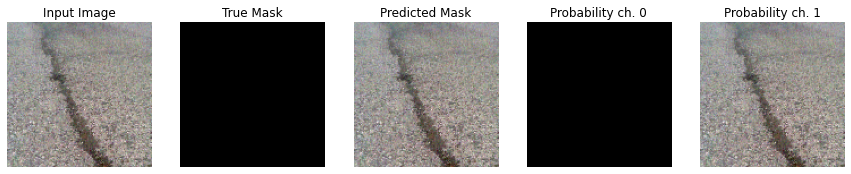

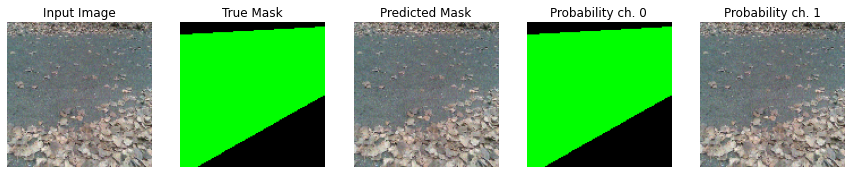

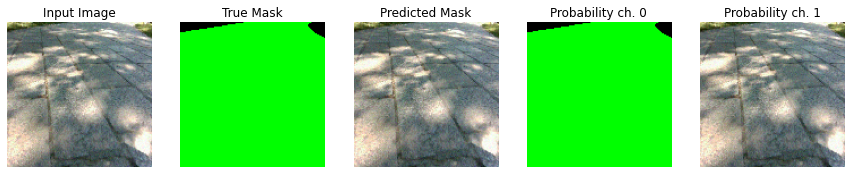

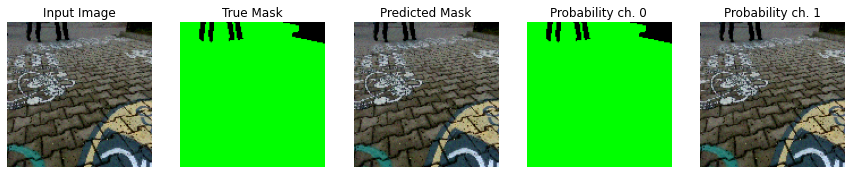

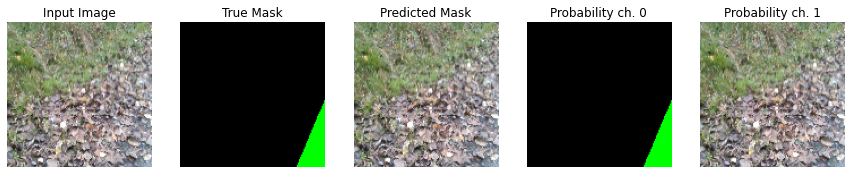

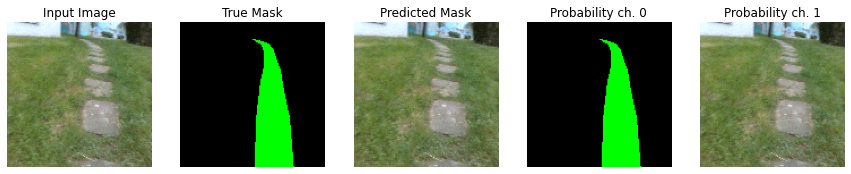

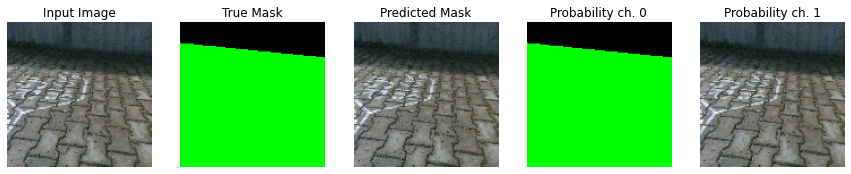

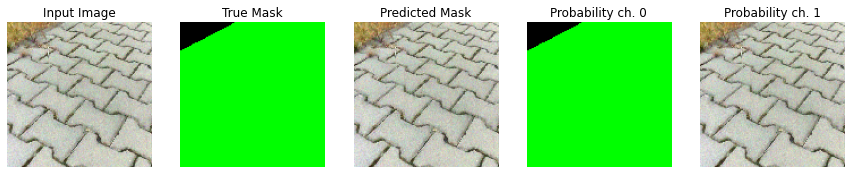

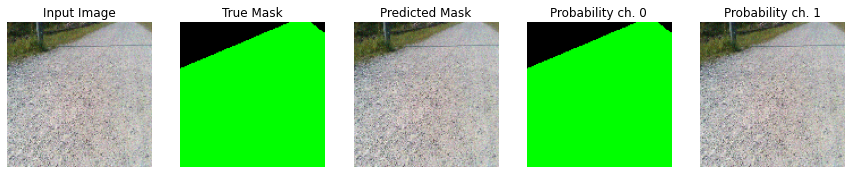

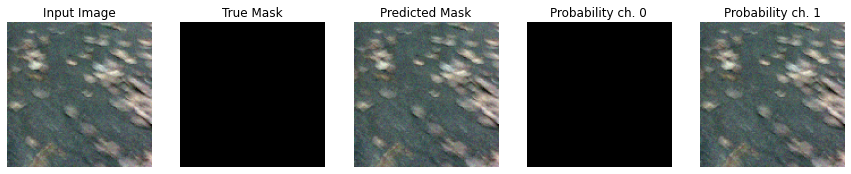

In [ ]:
for image, mask in train1_dataset.take(10):
  #print(mask[0])
  display([image[0], mask[0], image[0], mask[0], image[0]])


In [ ]:
#model=tf.keras.models.load_model('/content/gdrive/MyDrive/models/Model61.1a/Model61.1_0.9545764327049255.h5')
#model.Name='Model61.1b'

#SaveTFLite(model, resultDir+'/models')

# Location of tflite model file (float32 or int8 quantized)

# Processed features (copy from Edge Impulse project)
for image, mask in test:
  #display([image, mask, create_mask(TFLitePredict("/content/gdrive/MyDrive/models/MyNet2.a/MyNet2.a_int8.tflite", image))[0]])
#  display([image, create_mask(TFLitePredict("/content/gdrive/MyDrive/models/Model96.2/Model96.2.tflite", image))[0], create_mask(TFLitePredict("/content/gdrive/MyDrive/models/Model96.2/Model96.2_int8.tflite", image))[0], create_mask(TFLitePredict("/content/gdrive/MyDrive/models/Model96.2/Model96.2_int16.tflite", image))[0]])
  display([image, mask, create_mask(TFLitePredict("/content/gdrive/MyDrive/qmodels/Model96.2/Model96.2.tflite", image))[0], create_mask(TFLitePredict("/content/gdrive/MyDrive/qmodels/Model96.2/Model96.2_int8.tflite", image))[0], create_mask(TFLitePredict("/content/gdrive/MyDrive/qmodels/Model96.2/Model96.2_int16.tflite", image))[0]])



Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for image, mask in train1_dataset.take(10):
  display([image[0], mask[0]])


Output hidden; open in https://colab.research.google.com to view.

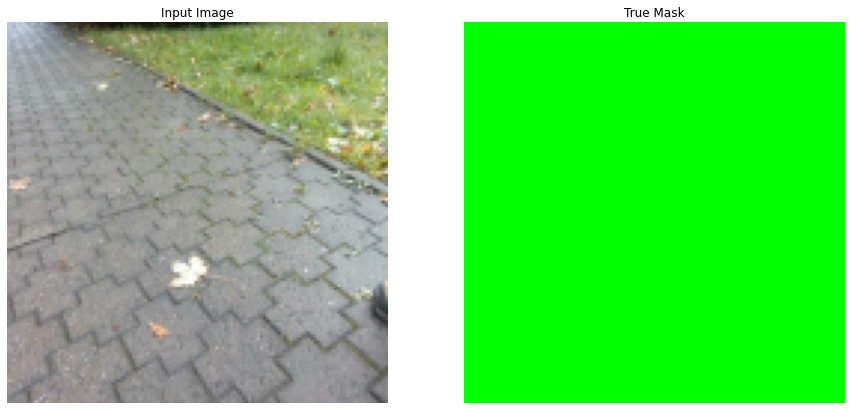

In [ ]:
i=np.array(image)
j=np.array(image)
j[:,:, ...]=[0, 1, 0]
display([i, j])

# New Section

## Modely


### Projekcni model

In [ ]:
# vlastni layer pro projekci barvy
class BackProjectLayer(tf.keras.layers.Layer):
  def __init__(self, back_project, num_outputs, **kwargs):
    super(BackProjectLayer, self).__init__(**kwargs)
    self.num_outputs = num_outputs
    self.back_project=back_project

#  def build(self, input_shape):
#    print(input_shape)

  def call(self, input):
    x=tf.dtypes.cast(tf.gather_nd(self.back_project, tf.dtypes.cast(tf.math.floor(input*255.0/16.0), tf.int32), batch_dims=0, name=None), tf.float32)
    return x

# model, ktery pocita puvodni algoritmus pomoci lookup table, nelze ho trenovat.
def BackProjectModel(shape, outputs):
  # projekce 4bit RGB na sjizdnost
  backProject=[
  [[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1], [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]
  , [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]
  ]

  model = keras.Sequential()
  model.add(BackProjectLayer(backProject, outputs, input_shape=shape))

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

# vytvoreni projekcniho modelu a vypocet jeho presnosti
bpmodel = BackProjectModel((96, 96, 3), 1)

SaveFrozenGraph(bpmodel, './models')

#print(ModelAccuracy(bpmodel, train))
#print(ModelAccuracy(bpmodel, test))




### Genericky model I

* shape - format vstupniho tensoru napr. (96, 96, 3)
* outputs - pocet vystupu, pro binarni obrazek 2
* encoder - popis encoderu list listu napr. [[64, 64] [128]] - 2 konvolucni vrstvy o 64 vystupech, max pooling, jedna konvolucni o 128 vystupech a max pooling, celkem se obrazek zmensi na 1/4
* decoder - popis decoderu list listu napr. [[64, 64] [16]] - upsampling, 2 konvolucni vrstvy o 64 vystupech, batch narmolization, upsampling, 1 konvolucni vrstva o 16 vystupech, batch narmolization, tj. zvetseni na 4 nasobek
* dense - list nasobku poctu vystupu dense verstev napr. [100, 10] - dense vrstva s outputs*100 vystupy, dropout(0,5), dense vrstva s outputs*10 vystupy, dropout(0,5)









In [ ]:
# generator modelu - pouziva UpSampling2D - nefunguje v TF Light
# name - jmeno modelu
# shape - format vstupniho tensoru napr. (96, 96, 3),
# outputs - pocet vystupu, pro binarni obrazek 2
# encoder - popis encoderu list listu napr. [[64, 64] [128]] - 2 konvolucni vrstvy o 64 vystupech, max pooling, jedna konvolucni o 128 vystupech a max pooling, celkem se obrazek zmensi na 1/4
# decoder - popis decoderu list listu napr. [[64, 64] [16]] - upsampling, 2 konvolucni vrstvy o 64 vystupech, batch narmolization, upsampling, 1 konvolucni vrstva o 16 vystupech, batch narmolization, tj. zvetseni na 4 nasobek
# dense - list nasobku poctu vystupu dense verstev napr. [100, 10] - dense vrstva s outputs*100 vystupy, dropout(0,5), dense vrstva s outputs*10 vystupy, dropout(0,5)
def GenericModel(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.ZeroPadding2D((1,1)))
      model.add(keras.layers.Convolution2D(i, 3, 1, activation='sigmoid'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))

  for de in decoder:
    model.add(keras.layers.UpSampling2D((2,2)))
    for i in de:
      model.add(keras.layers.ZeroPadding2D((1,1)))
      model.add(keras.layers.Convolution2D(i, 3, 1, activation='sigmoid'))
    model.add(keras.layers.BatchNormalization())

  for i in dense:
    model.add(keras.layers.Dense(i*outputs, activation='relu'))
    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Dense(outputs, activation='softmax'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

# generator modelu - pouziva Conv2DTranspose - funguje v TF Light
# name - jmeno modelu
# shape - format vstupniho tensoru napr. (96, 96, 3),
# outputs - pocet vystupu, pro binarni obrazek 2
# encoder - popis encoderu list listu napr. [[64, 64] [128]] - 2 konvolucni vrstvy o 64 vystupech, max pooling, jedna konvolucni o 128 vystupech a max pooling, celkem se obrazek zmensi na 1/4
# decoder - popis decoderu list listu napr. [[64, 64] [16]] - upsampling, 2 konvolucni vrstvy o 64 vystupech, batch narmolization, upsampling, 1 konvolucni vrstva o 16 vystupech, batch narmolization, tj. zvetseni na 4 nasobek
# dense - list nasobku poctu vystupu dense verstev napr. [100, 10] - dense vrstva s outputs*100 vystupy, dropout(0,5), dense vrstva s outputs*10 vystupy, dropout(0,5)
def GenericModel2(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.ZeroPadding2D((1,1)))
      model.add(keras.layers.Convolution2D(i, 3, 1, activation='sigmoid'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))

  for de in decoder:
    print(i)
    l=keras.layers.Conv2DTranspose(i, kernel_size=(2,2), strides=(2,2), activation='sigmoid')
    model.add(l)
    for i in de:
      model.add(keras.layers.ZeroPadding2D((1,1)))
      model.add(keras.layers.Convolution2D(i, 3, 1, activation='sigmoid'))
    model.add(keras.layers.BatchNormalization())

  for i in dense:
    model.add(keras.layers.Dense(i*outputs, activation='relu'))
    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Dense(outputs, activation='softmax'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel3(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.ZeroPadding2D((1,1)))
      model.add(keras.layers.Convolution2D(i, 3, 1, activation='relu'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))

  for de in decoder:
    model.add(keras.layers.UpSampling2D((2,2)))
    for i in de:
      model.add(keras.layers.ZeroPadding2D((1,1)))
      model.add(keras.layers.Convolution2D(i, 3, 1, activation='relu'))
    model.add(keras.layers.BatchNormalization())

  for i in dense:
    model.add(keras.layers.Dense(i*outputs, activation='relu'))
    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Dense(outputs, activation='softmax'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel4(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.ZeroPadding2D((1,1)))
      model.add(keras.layers.Convolution2D(i, 3, 1, activation='sigmoid'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))

  for de in decoder:
    model.add(keras.layers.UpSampling2D((2,2)))
    for i in de:
      model.add(keras.layers.ZeroPadding2D((1,1)))
      model.add(keras.layers.Convolution2D(i, 3, 1, activation='sigmoid'))
    model.add(keras.layers.BatchNormalization())

  for i in dense:
    model.add(keras.layers.Dense(i*outputs, activation='sigmoid'))
    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Dense(outputs, activation='sigmoid'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model


def GenericModel5(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))

  for de in decoder:
    model.add(keras.layers.UpSampling2D((2,2)))
    for i in de:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.BatchNormalization())

  for i in dense:
    model.add(keras.layers.Dense(i*outputs, activation='sigmoid'))
    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Dense(outputs, activation='sigmoid'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model



def GenericModel6(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])
  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))
    size=(size[0]/2, size[1]/2)

  for de in decoder:
    size=(size[0]*2, size[1]*2)
    model.add(Resize(size, i))
    for i in de:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.BatchNormalization())

  for i in dense:
#    model.add(keras.layers.Dense(i*outputs, activation='sigmoid'))
    model.add(keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Convolution2D(outputs, 1, 1, padding='same', activation='sigmoid'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel7(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])
  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))
    size=(size[0]/2, size[1]/2)

  for de in decoder:
    size=(size[0]*2, size[1]*2)
    model.add(Resize(size, i))
    for i in de:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.BatchNormalization())

  for i in dense:
#    model.add(keras.layers.Dense(i*outputs, activation='sigmoid'))
    model.add(keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', activation='sigmoid'))
#    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Convolution2D(outputs, 1, 1, padding='same', activation='sigmoid'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel8(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])
  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))
    size=(size[0]/2, size[1]/2)

  for de in decoder:
    size=(size[0]*2, size[1]*2)
    model.add(Resize(size, i))
    for i in de:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
#    model.add(keras.layers.BatchNormalization())

  for i in dense:
#    model.add(keras.layers.Dense(i*outputs, activation='sigmoid'))
    model.add(keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', activation='sigmoid'))
#    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Convolution2D(outputs, 1, 1, padding='same', activation='sigmoid'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model


def GenericModel9(name, shape, outputs, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])
  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))
    model.add(keras.layers.BatchNormalization())
    size=(size[0]/2, size[1]/2)

  for de in decoder:
    size=(size[0]*2, size[1]*2)
    model.add(Resize(size, i))
    for i in de:
      model.add(keras.layers.Convolution2D(i, 3, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.BatchNormalization())

  for i in dense:
#    model.add(keras.layers.Dense(i*outputs, activation='sigmoid'))
    model.add(keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', activation='sigmoid'))
#    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Convolution2D(outputs, 1, 1, padding='same', activation='sigmoid'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel10(name, shape, outputs, expansion, momentum, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])
  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for en in encoder:
    for i in en:
      model.add(keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      model.add(keras.layers.ReLU())
      model.add(keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      model.add(keras.layers.ReLU())
      model.add(keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
    model.add(keras.layers.MaxPooling2D((2,2), strides=(2,2)))
    model.add(keras.layers.BatchNormalization(momentum=momentum))
    size=(size[0]/2, size[1]/2)

  for de in decoder:
    size=(size[0]*2, size[1]*2)
    model.add(Resize(size, i))
    for i in de:
      model.add(keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      model.add(keras.layers.ReLU())
      model.add(keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      model.add(keras.layers.ReLU())
      model.add(keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
    model.add(keras.layers.BatchNormalization(momentum=momentum))

  for i in dense:
#    model.add(keras.layers.Dense(i*outputs, activation='sigmoid'))
    model.add(keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', activation='sigmoid'))
#    model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Convolution2D(outputs, 1, 1, padding='same', activation='sigmoid'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel11(name, shape, outputs, expansion, momentum, encoder, enDense, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])
  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))
  model.add(keras.layers.BatchNormalization(momentum=momentum))

  for en in encoder:
    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      model.add(keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      model.add(keras.layers.ReLU())
      model.add(keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      model.add(keras.layers.ReLU())
      model.add(keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      last_i=i
    size=(size[0]/2, size[1]/2)

  print(model.output_shape)

  model.add(keras.layers.Flatten())

  print(model.output_shape)

  for i in enDense:
    model.add(keras.layers.Dense(i*size[0]*size[1], activation='sigmoid'))
    model.add(keras.layers.BatchNormalization(momentum=momentum))
  model.add(keras.layers.Dense(last_i*size[0]*size[1], activation='sigmoid'))
  model.add(keras.layers.BatchNormalization(momentum=momentum))

  model.add(keras.layers.Reshape([int(size[0]), int(size[1]), last_i]))

  for de in decoder:
    size=(size[0]*2, size[1]*2)
    model.add(Resize(size, i))
    for i in de:
      model.add(keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      model.add(keras.layers.ReLU())
      model.add(keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))
      model.add(keras.layers.ReLU())
      model.add(keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None))
      model.add(keras.layers.BatchNormalization(momentum=momentum))

  for i in dense:
#    model.add(keras.layers.Dense(i*outputs, activation='sigmoid'))
    model.add(keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', activation='sigmoid'))
    model.add(keras.layers.BatchNormalization(momentum=momentum))
  model.add(keras.layers.Convolution2D(outputs, 1, 1, padding='same', activation='sigmoid'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel12(name, shape, outputs, expansion, momentum, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])
  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for iii in range(len(encoder)):
    en=encoder[iii]
    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      model.add(keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN'))
      model.add(keras.layers.ReLU(name=prefix+ '_expand_ReLU'))
      model.add(keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation=None, name=prefix+ '_depth'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN'))
      model.add(keras.layers.ReLU(name=prefix+ '_depth_ReLU'))
      model.add(keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN'))
      last_i=i
    size=(size[0]/2, size[1]/2)

  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    model.add(Resize(size, i))
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      model.add(keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN'))
      model.add(keras.layers.ReLU(name=prefix+ '_expand_ReLU'))
      model.add(keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_depth'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN'))
      model.add(keras.layers.ReLU(name=prefix+ '_depth_ReLU'))
      model.add(keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN'))

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    model.add(keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv'))
    model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN'))
    model.add(keras.layers.ReLU(name=prefix+ '_ReLU'))
  model.add(keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation=None, name='final_conv'))
  model.add(keras.layers.BatchNormalization(momentum=momentum, name='final_BN'))
  model.add(keras.layers.ReLU(name='final_ReLU'))

  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel13(name, shape, outputs, expansion, momentum, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])
  model = keras.Sequential(name=name)
  model.add(keras.layers.InputLayer(input_shape=shape))

  for iii in range(len(encoder)):
    en=encoder[iii]
    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      model.add(keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN'))
      model.add(keras.layers.ReLU(name=prefix+ '_expand_ReLU'))
      model.add(keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation=None, name=prefix+ '_depth'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN'))
      model.add(keras.layers.ReLU(name=prefix+ '_depth_ReLU'))
      model.add(keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN'))
      last_i=i
    size=(size[0]/2, size[1]/2)

  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    model.add(Resize(size, i))
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      model.add(keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN'))
      model.add(keras.layers.ReLU(name=prefix+ '_expand_ReLU'))
      model.add(keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_depth'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN'))
      model.add(keras.layers.ReLU(name=prefix+ '_depth_ReLU'))
      model.add(keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project'))
      model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN'))

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    model.add(keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv'))
    model.add(keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN'))
    model.add(keras.layers.ReLU(name=prefix+ '_ReLU'))
  model.add(keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation='sigmoid', name='final_conv'))
#  model.add(keras.layers.ReLU(name='final_ReLU'))

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-8), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model


#model16=GenericModel6('Model16', (96, 96, 3), 2, [[4], [4], [8], [8], [16]], [[16], [16], [8], [8], [8]], [10, 3])
#SaveFrozenGraph(model16, './models')

#model17=GenericModel7('Model17', (96, 96, 3), 2, [[4], [4], [8], [8], [16]], [[16], [16], [8], [8], [8]], [10, 3])
#SaveFrozenGraph(model17, './models')

#model18=GenericModel8('Model18', (96, 96, 3), 2, [[4], [4], [8], [8], [16]], [[16], [16], [8], [8], [8]], [10, 3])
#SaveFrozenGraph(model18, './models')

# to same co 18
#model19=GenericModel8('Model19', (96, 96, 3), 2, [[4], [4], [8], [8], [16]], [[16], [16], [8], [8], [8]], [10, 3])
#SaveFrozenGraph(model19, './models')

#model20=GenericModel8('Model20', (96, 96, 3), 2, [[8], [8], [16], [16], [32]], [[32], [32], [32], [16], [16]], [50, 25, 8])
#SaveFrozenGraph(model20, './models')


#model21=GenericModel8('Model21', (96, 96, 3), 2, [[8], [16], [32], [64], [128]], [[64], [64], [32], [32], [32]], [50, 30, 15])
#SaveFrozenGraph(model21, './models')


#model22=GenericModel9('Model22', (96, 96, 3), 2, [[8], [16], [32], [64], [128]], [[64], [64], [32], [32], [32]], [50, 30, 15])
#SaveFrozenGraph(model22, './models')

#model23=GenericModel9('Model23', (96, 96, 3), 2, [[16], [32], [64], [128], [128]], [[128], [128], [64], [64], [64]], [50, 30, 15])
#SaveFrozenGraph(model23, './models')

#model24=GenericModel9('Model24', (128, 128, 3), 2, [[16], [32], [64], [128], [256], [512], [1024]], [[512], [256], [128], [128], [64], [64], [64]], [50, 30, 15])
#model25=GenericModel9('Model25', (96, 96, 3), 2, [[16, 16], [32, 32], [64, 64], [128, 128], [256, 256]], [[128, 128], [128, 128], [64, 64], [64, 64], [64, 64]], [50, 50, 30, 30, 15, 15])

#model26=GenericModel10('Model26', (96, 96, 3), 2, 1, [[16, 16], [32, 32], [64, 64], [128, 128], [256, 256]], [[128, 128], [128, 128], [64, 64], [64, 64], [64, 64]], [50, 50, 30, 30, 15, 15])

#model27=GenericModel10('Model27', (96, 96, 3), 2, 6, [[16, 16], [32, 32], [64, 64], [128, 128], [256, 256]], [[128, 128], [128, 128], [64, 64], [64, 64], [64, 64]], [50, 50, 30, 30, 15, 15])

#batch 1, BatchNormalization momentum 0.99
#model28=GenericModel10('Model28', (96, 96, 3), 2, 1, 0.99, [[16], [32], [64], [128], [256]], [[128], [128], [64], [64], [64]], [50, 30, 15])
#batch 10, BatchNormalization momentum 0.99
#model28a=GenericModel10('Model28a', (96, 96, 3), 2, 1, 0.99, [[16], [32], [64], [128], [256]], [[128], [128], [64], [64], [64]], [50, 30, 15])
#batch 1, BatchNormalization momentum 0.999
#model28b=GenericModel10('Model28b', (96, 96, 3), 2, 1, 0.999, [[16], [32], [64], [128], [256]], [[128], [128], [64], [64], [64]], [50, 30, 15])
#batch 1, BatchNormalization momentum 0.995
#model28c=GenericModel10('Model28c', (96, 96, 3), 2, 4, 0.995, [[16], [32], [64], [128], [256]], [[128], [128], [64], [64], [64]], [50, 30, 15])
#model28d=GenericModel10('Model28d', (96, 96, 3), 2, 4, 0.995, [[16], [32], [64], [128], [256]], [[128], [128], [64], [64], [64]], [50, 30, 15])
#model29=GenericModel10('Model29', (96, 96, 3), 2, 4, 0.995, [[16], [32], [64], [128], [256]], [[128], [128], [64], [64], [64]], [50, 40, 30, 25, 15, 10])
#model30=GenericModel11('Model30', (96, 96, 3), 2, 4, 0.995, [[16], [32], [64], [128], [256]], [64, 64, 64], [[128], [128], [64], [64], [64]], [50, 40, 30, 25, 15, 10])
#model31=GenericModel11('Model31', (96, 96, 3), 2, 4, 0.995, [[16], [32], [64], [128], [256]], [], [[128], [128], [64], [64], [64]], [50, 30, 15])
#model32=GenericModel11('Model32', (96, 96, 3), 2, 4, 0.995, [[16], [32], [32], [64], [64]], [], [[64], [64], [64], [32], [32]], [50, 30, 15])
#model33=GenericModel12('Model33', (96, 96, 3), 2, 4, 0.995, [[16], [32], [32], [64, 64, 64], [128, 128, 128]], [[64, 64], [64, 64], [64, 64], [32, 32], [32, 32]], [50, 30, 15])
#model34=GenericModel12('Model34', (96, 96, 3), 2, 4, 0.995, [[16], [32], [64], [128], [256]], [[128], [128], [64], [64], [64]], [50, 30, 15])
#model35=GenericModel13('Model35', (96, 96, 3), 2, 4, 0.995, [[16], [32], [64], [128], [256]], [[128], [128], [64], [64], [64]], [50, 30, 15])
#model36=GenericModel13('Model36', (96, 96, 3), 2, 4, 0.999, [[16, 16, 16], [32, 32, 32], [64, 64, 64], [128, 128, 128, 128], [128, 128, 128]], [[128, 128, 128], [128, 128, 128], [64, 64, 64], [64, 64, 64], [64, 64, 64]], [50, 30, 15])
#model37=GenericModel13('Model37', (96, 96, 3), 2, 3, 0.999, [[16, 16, 16], [32, 32, 32], [64, 64, 64], [64, 64, 64, 64], [64, 64, 64]], [[64, 64, 64], [64, 64, 64], [64, 64, 64], [32, 32, 32], [32, 32, 32]], [50, 30, 15])




###Genericky model II

In [ ]:
def GenericModel14(name, shape, outputs, expansion, momentum, dtype, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype)

  skip=[]
  ll=inputs

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation=None, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=Resize(size, i)(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)

    print(iii)

    al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv', dtype=dtype)(skip[len(decoder)-1-iii])
    ll=keras.layers.Add(dtype=dtype)([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation='sigmoid', name='final_conv', dtype=dtype)(ll)
#  model.add(keras.layers.ReLU(name='final_ReLU'))

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel15(name, shape, outputs, expansion, momentum, dtype, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype)

  skip=[]
  ll=inputs

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation='sigmoid', name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation='sigmoid', name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation='sigmoid', name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=Resize(size, i)(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation='sigmoid', name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation='sigmoid', name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation='sigmoid', name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)

    print(iii)

    al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=False, activation='sigmoid', name=prefix+ '_conv', dtype=dtype)(skip[len(decoder)-1-iii])
    ll=keras.layers.Add(dtype=dtype)([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation='sigmoid', name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation='sigmoid', name='final_conv', dtype=dtype)(ll)
#  model.add(keras.layers.ReLU(name='final_ReLU'))

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model




def GenericModel16(name, shape, outputs, expansion, momentum, dtype, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype)

  skip=[]
  ll=inputs

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation=None, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=Resize(size, i)(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)

    print(iii)

    al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv', dtype=dtype)(skip[len(decoder)-1-iii])
    ll=keras.layers.Concatenate(axis=3, dtype=dtype)([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation='sigmoid', name='final_conv', dtype=dtype)(ll)
#  model.add(keras.layers.ReLU(name='final_ReLU'))

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel17(name, shape, outputs, expansion, momentum, dtype, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype)

  skip=[]
  ll=inputs

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation=None, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=keras.layers.UpSampling2D(size=(2, 2))(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)

    print(iii)

    al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv', dtype=dtype)(skip[len(decoder)-1-iii])
    ll=keras.layers.Concatenate(axis=3, dtype=dtype)([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation='sigmoid', name='final_conv', dtype=dtype)(ll)
#  model.add(keras.layers.ReLU(name='final_ReLU'))

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel18(name, shape, outputs, expansion, momentum, dtype, encoder, decoder, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  reluMax=None
  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype, name='input')

  skip=[]
  ll=inputs

# v imagenet tohle taky neni
#  ll=keras.layers.BatchNormalization(momentum=momentum, name='input_BN', dtype=dtype)(ll)
#  ll=keras.layers.ReLU(reluMax, name='input_ReLU', dtype=dtype)(ll)

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation=None, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=keras.layers.UpSampling2D(size=(2, 2), name='decoder_{}_UpSampling'.format(iii))(ll)
#    ll=keras.layers.Conv2DTranspose(i, kernel_size=(2,2), strides=(2,2), activation=None)(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)

    print(iii)

    al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv', dtype=dtype)(skip[len(decoder)-1-iii])
    al=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_conv_BN', dtype=dtype)(ll)
    al=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
    ll=keras.layers.Concatenate(axis=3, dtype=dtype, name=prefix+ '_concatenate')([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation=None, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(reluMax, name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation=None, name='final_conv', dtype=dtype)(ll)

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  #model = tfmot.quantization.keras.quantize_model(model)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

#model38=GenericModel14('Model38', (96, 96, 3), 2, 3, 0.999, 'float32', [[16, 16, 16], [32, 32, 32], [64, 64, 64], [64, 64, 64, 64], [64, 64, 64]], [[64, 64, 64], [64, 64, 64], [64, 64, 64], [32, 32, 32], [32, 32, 32]], [50, 30, 15])
#model39=GenericModel14('Model39', (96, 96, 3), 2, 3, 0.999, 'float32', [[8, 8], [16, 16], [32, 32], [32, 32], [64, 64, 64]], [[64, 64, 64], [32, 32], [32, 32], [16, 16], [8, 8]], [50, 30, 15])
#model40=GenericModel14('Model40', (96, 96, 3), 2, 3, 0.995, 'float32', [[8, 8], [16, 16], [32, 32], [32, 32], [64, 64, 64]], [[64, 64, 64], [32, 32], [32, 32], [16, 16], [8, 8]], [])
#model41=GenericModel14('Model41', (96, 96, 3), 2, 3, 0.995, 'float32', [[8, 8], [16, 16], [32, 32], [32, 32], [64, 64, 64]], [[64, 64, 64], [32, 32], [32, 32], [32, 32], [32, 32]], [])
#model42=GenericModel15('Model42', (96, 96, 3), 2, 3, 0.995, 'float32', [[8, 8], [16, 16], [32, 32], [32, 32], [64, 64, 64]], [[64, 64, 64], [32, 32], [32, 32], [32, 32], [32, 32]], [])
#model43=GenericModel16('Model43', (96, 96, 3), 2, 3, 0.995, 'float32', [[8, 8], [16, 16], [32, 32], [32, 32], [64, 64, 64]], [[64, 64, 64], [32, 32], [32, 32], [32, 32], [32, 32]], [])
#model44=GenericModel16('Model44', (96, 96, 3), 2, 6, 0.99, 'float32', [[16, 16, 16], [32, 32, 32], [64, 64, 64], [128, 128, 128], [256, 256, 256]], [[256, 256, 256], [128, 128, 128], [64, 64, 64], [64, 64, 64], [64, 64, 64]], [])
model46=GenericModel17('Model46', (96, 96, 3), 2, 6, 0.99, 'float32', [[16, 16, 32], [32, 32, 64], [64, 64, 128], [128, 128, 256], [256, 256, 256]], [[256, 256, 256], [128, 128, 128], [64, 64, 64], [64, 64, 64], [64, 64, 64]], [])
#model49=GenericModel17('Model49', (96, 96, 3), 2, 1, 0.99, 'float32', [[8, 16], [16, 16], [16, 32], [32, 32], [32, 32]], [[32, 32], [32, 32], [32, 32], [16, 16], [16, 16]], [])
#model50=GenericModel18('Model50', (96, 96, 3), 2, 6, 0.99, 'float32', [[16, 16, 32], [32, 32, 64], [64, 64, 128], [128, 128, 256], [256, 256, 256]], [[256, 256, 256], [128, 128, 128], [64, 64, 64], [64, 64, 64], [64, 64, 64]], [])


NameError: ignored

###MobileNet III

In [ ]:
def GenericModel19(name, shape, outputs, expansion, momentum, dtype, encoder, decoder, skips, dense):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  if len(skips)!=len(decoder):
    print('Lenght of skips and decoder must be equal.')
    return

  reluMax=None
  useRelu=True
  activation=None


  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype, name='input')

  skip=[]
  ll=inputs

# v imagenet tohle taky neni
#  ll=keras.layers.BatchNormalization(momentum=momentum, name='input_BN', dtype=dtype)(ll)
#  ll=keras.layers.ReLU(reluMax, name='input_ReLU', dtype=dtype)(ll)

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, strides, padding='same', use_bias=False, activation=activation, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
#nasledujici relu neni v 17
#      if useRelu:
#        ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=keras.layers.UpSampling2D(size=(2, 2), name='decoder_{}_UpSampling'.format(iii))(ll)
#    ll=keras.layers.Conv2DTranspose(i, kernel_size=(2,2), strides=(2,2), activation=None)(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.DepthwiseConv2D(3, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
#tohle neni v 17
#      if useRelu:
#        ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)

    print(iii)

    if skips[len(decoder)-1-iii]:
      al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_conv', dtype=dtype)(skip[len(decoder)-1-iii])
#tohle neni v 17
#    al=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_conv_BN', dtype=dtype)(ll)
#    if useRelu:
#      al=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Concatenate(axis=3, dtype=dtype, name=prefix+ '_concatenate')([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    if useRelu:
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation='sigmoid', name='final_conv', dtype=dtype)(ll)

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  #model = tfmot.quantization.keras.quantize_model(model)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

def GenericModel20(name, shape, outputs, expansion, momentum, dropoutRate, dtype, encoder, decoder, skips, dense, kernel=3):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  if len(skips)!=len(decoder):
    print('Lenght of skips and decoder must be equal.')
    return

  reluMax=None
  useRelu=True
  activation=None

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype, name='input')

  skip=[]
  ll=inputs

# v imagenet tohle taky neni
#  ll=keras.layers.BatchNormalization(momentum=momentum, name='input_BN', dtype=dtype)(ll)
#  ll=keras.layers.ReLU(reluMax, name='input_ReLU', dtype=dtype)(ll)

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_expand_Dropout')(ll)
      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, strides, padding='same', use_bias=False, activation=activation, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
#nasledujici relu neni v 17
#      if useRelu:
#        ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=keras.layers.UpSampling2D(size=(2, 2), name='decoder_{}_UpSampling'.format(iii))(ll)
#    ll=keras.layers.Conv2DTranspose(i, kernel_size=(2,2), strides=(2,2), activation=None)(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_expand_Dropout')(ll)
      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
#tohle neni v 17
#      if useRelu:
#        ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)

    print(iii)

    if skips[len(decoder)-1-iii]:
      al=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(skip[len(decoder)-1-iii])
      al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_conv', dtype=dtype)(al)
#tohle neni v 17
#    al=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_conv_BN', dtype=dtype)(ll)
#    if useRelu:
#      al=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Concatenate(axis=3, dtype=dtype, name=prefix+ '_concatenate')([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(ll)
    ll=keras.layers.Convolution2D(i*outputs, 1, 1, padding='same', use_bias=False, activation=activation, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    if useRelu:
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_final_conv_Dropout')(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False, activation='sigmoid', name='final_conv', dtype=dtype)(ll)

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  #model = tfmot.quantization.keras.quantize_model(model)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()
  print('Flops: {:,}'.format(get_flops(model)))

  return model

def GenericModel24(name, shape, outputs, kernel_reg, use_bias, expansion, momentum, dropoutRate, dtype, encoder, decoder, skips, dense, kernel=3):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  if len(skips)!=len(decoder):
    print('Lenght of skips and decoder must be equal.')
    return

  reluMax=None
  useRelu=True
  activation=None

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype, name='input')

  skip=[]
  ll=inputs

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    ls=ll

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
        ls=keras.layers.Convolution2D(last_i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_skip', dtype=dtype, kernel_regularizer=kernel_reg)(ls)
        ll=keras.layers.Add()([ll, ls])
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_expand_Dropout')(ll)
      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_expand', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, strides, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_depth', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=keras.layers.UpSampling2D(size=(2, 2), name='decoder_{}_UpSampling'.format(iii))(ll)
#    ll=keras.layers.Conv2DTranspose(i, kernel_size=(2,2), strides=(2,2), activation=None)(ll)

    ls=ll

    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_expand_Dropout')(ll)
      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_expand', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_depth', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)

    print(iii)


    if skips[len(decoder)-1-iii]:
      ls=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_skip', dtype=dtype, kernel_regularizer=kernel_reg)(ls)
      ll=keras.layers.Add()([ll, ls])
      al=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(skip[len(decoder)-1-iii])
      al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype, kernel_regularizer=kernel_reg)(al)
      ll=keras.layers.Concatenate(axis=3, dtype=dtype, name=prefix+ '_concatenate')([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(ll)
    ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    if useRelu:
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_final_conv_Dropout')(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=use_bias, activation='sigmoid', name='final_conv', dtype=dtype, kernel_regularizer=kernel_reg)(ll)

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  #model = tfmot.quantization.keras.quantize_model(model)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model

# podobne jako GenericModel20, ale posledni encoder nedela downsample (na nejmensim orzliseni byly jen 2 vrstvy)
def GenericModel25(name, shape, outputs, expansion, momentum, dropoutRate, dtype, encoder, decoder, skips, dense, kernel=3, defStrides=2, use_bias=False):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  if len(skips)!=len(decoder):
    print('Lenght of skips and decoder must be equal.')
    return

  reluMax=None
  useRelu=True
  activation=None

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype, name='input')

  skip=[]
  sizes=[]
  stridess=[]
  ll=inputs

# v imagenet tohle taky neni
#  ll=keras.layers.BatchNormalization(momentum=momentum, name='input_BN', dtype=dtype)(ll)
#  ll=keras.layers.ReLU(reluMax, name='input_ReLU', dtype=dtype)(ll)

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1 and iii!=len(encoder)-1:
        strides=defStrides
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_expand_Dropout')(ll)
      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, strides, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
#nasledujici relu neni v 17
#      if useRelu:
#        ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)
      last_i=i
    sizes=sizes+[size]
    size=(size[0]/strides, size[1]/strides)
    stridess=stridess+[strides]


  print(size)
  print(stridess)
  print(sizes)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=sizes[len(decoder)-1-iii]
    if stridess[len(decoder)-1-iii]>1:
      ll=keras.layers.UpSampling2D(size=(stridess[len(decoder)-1-iii], stridess[len(decoder)-1-iii]), name='decoder_{}_UpSampling'.format(iii))(ll)
#    ll=keras.layers.Conv2DTranspose(i, kernel_size=(2,2), strides=(2,2), activation=None)(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_expand_Dropout')(ll)
      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
#tohle neni v 17
#      if useRelu:
#        ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)

    print(iii)

    if skips[len(decoder)-1-iii]:
      al=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(skip[len(decoder)-1-iii])
      al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype)(al)
#tohle neni v 17
#    al=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_conv_BN', dtype=dtype)(ll)
#    if useRelu:
#      al=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Concatenate(axis=3, dtype=dtype, name=prefix+ '_concatenate')([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(ll)
    ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    if useRelu:
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_final_conv_Dropout')(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=use_bias, activation='sigmoid', name='final_conv', dtype=dtype)(ll)

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  #model = tfmot.quantization.keras.quantize_model(model)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()
  print('Flops: {:,}'.format(get_flops(model)))

  return model

# podobne jako GenericModel20, ale posledni encoder nedela downsample (na nejmensim orzliseni byly jen 2 vrstvy)
# proti GenericModel25 doplnen maxpool2d
def GenericModel26(name, shape, outputs, expansion, momentum, dropoutRate, dtype, preDense, encoder, decoder, skips, dense, kernel=3, defStrides=2, use_bias=False):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  if len(skips)!=len(decoder):
    print('Lenght of skips and decoder must be equal.')
    return

  reluMax=None
  useRelu=True
  activation=None

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype, name='input')

  skip=[]
  sizes=[]
  stridess=[]
  ll=inputs

# v imagenet tohle taky neni
#  ll=keras.layers.BatchNormalization(momentum=momentum, name='input_BN', dtype=dtype)(ll)
#  ll=keras.layers.ReLU(reluMax, name='input_ReLU', dtype=dtype)(ll)

  for ii in range(len(preDense)):
    i=preDense[ii]

    prefix='preDense_{}'.format(ii)

    ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(ll)
    ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    if useRelu:
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_ReLU', dtype=dtype)(ll)


  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1 and iii!=len(encoder)-1:
        strides=defStrides
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_expand_Dropout')(ll)
      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      if strides!=1:
#        ll=keras.layers.MaxPooling2D(strides, strides, padding='same', name=prefix+ '_MaxPooling', dtype=dtype)(ll)
        ll=keras.layers.DepthwiseConv2D(strides, strides, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_DownSample', dtype=dtype)(ll)
#nasledujici relu neni v 17
#      if useRelu:
#        ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)
      last_i=i
    sizes=sizes+[size]
    size=(size[0]/strides, size[1]/strides)
    stridess=stridess+[strides]


  print(size)
  print(stridess)
  print(sizes)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=sizes[len(decoder)-1-iii]
    if stridess[len(decoder)-1-iii]>1:
      ll=keras.layers.UpSampling2D(size=(stridess[len(decoder)-1-iii], stridess[len(decoder)-1-iii]), name='decoder_{}_UpSampling'.format(iii))(ll)
#    ll=keras.layers.Conv2DTranspose(i, kernel_size=(2,2), strides=(2,2), activation=None)(ll)
    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_expand_Dropout')(ll)
      ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_expand', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_expand_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_expand_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_depth', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
#tohle neni v 17
#      if useRelu:
#        ll=keras.layers.ReLU(reluMax, name=prefix+ '_project_ReLU', dtype=dtype)(ll)

    print(iii)

    if skips[len(decoder)-1-iii]:
      al=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(skip[len(decoder)-1-iii])
      al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype)(al)
#tohle neni v 17
#    al=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_conv_BN', dtype=dtype)(ll)
#    if useRelu:
#      al=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Concatenate(axis=3, dtype=dtype, name=prefix+ '_concatenate')([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(ll)
    ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
    if useRelu:
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_final_conv_Dropout')(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=use_bias, activation='sigmoid', name='final_conv', dtype=dtype)(ll)

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  #model = tfmot.quantization.keras.quantize_model(model)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()
  print('Flops: {:,}'.format(get_flops(model)))

  return model


#model51=GenericModel19('Model51', (96, 96, 3), 2, 6, 0.99, 'float32', [[16, 16, 32], [32, 32, 64], [64, 64, 128], [128, 128, 256], [256, 256, 256]], [[256, 256, 256], [128, 128, 128], [64, 64, 64], [64, 64, 64], [64, 64, 64]], [True, True, True, True, True], [])
#model52=GenericModel19('Model52', (96, 96, 3), 2, 3, 0.99, 'float32', [[16, 16, 32], [32, 32, 64], [64, 64, 128], [128, 128, 256], [256, 256, 256]], [[256, 256, 256], [128, 128, 128], [64, 64, 64], [64, 64, 64], [64, 64, 64]], [True, True, True, True, True], [])
#model53=GenericModel19('Model53', (96, 96, 3), 2, 4, 0.99, 'float32', [[8, 8, 16], [16, 16, 32], [32, 64, 64], [64, 64, 128], [128, 128, 256]], [[256, 256, 128], [128, 128, 64], [64, 64, 32], [32, 32, 16], [16, 16, 16]], [False, False, True, True, True], [])
#model54 velmi pekne vysledky
#model54=GenericModel20('Model54.3', (96, 96, 3), 2, 4, 0.99, 0.2, 'float32', [[8, 8, 16], [16, 16, 32], [32, 64, 64], [64, 64, 128], [128, 128, 256]], [[256, 256, 128], [128, 128, 64], [64, 64, 32], [32, 32, 16], [16, 16, 16]], [False, False, True, True, True], [])
#tohle se dostalo jen 93% accuracy a jeden travnik to identifikovalo jako sjizdny
#model55=GenericModel20('Model55.1', (96, 96, 3), 2, 4, 0.99, 0.2, 'float32', [[4, 4, 8], [8, 8, 16], [16, 16, 32], [32, 32, 64], [64, 64, 128]], [[128, 128, 64], [64, 64, 32], [32, 32, 16], [16, 16, 8], [8, 8, 8]], [False, False, True, True, True], [])
#model56=GenericModel20('Model56.1', (96, 96, 3), 2, 4, 0.99, 0.2, 'float32', [[8, 8, 16], [16, 16, 16], [16, 16, 32], [32, 32, 64], [64, 64, 128]], [[128, 128, 64], [64, 64, 64], [64, 64, 32], [32, 32, 32], [32, 32, 16]], [False, False, True, True, True], [])
#model57=GenericModel20('Model57.1', (96, 96, 3), 2, 4, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128]], [[128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True], [])
#model=GenericModel20('Model57.2', (shape[0], shape[1], 3), 2, 4, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128]], [[128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True], [])
#model=GenericModel20('Model57.3', (shape[0], shape[1], 3), 2, 4, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128]], [[128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True], [])
#model=GenericModel20('Model58.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256], [256, 256]], [[256, 256], [256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, False, True, True, True, True], [])
#model=GenericModel20('Model59.2', (shape[0], shape[1], 3), 2, 1, 0.99, 0.05, 'float32', [[4, 4], [4, 8], [8, 8], [8, 16], [16, 16], [16, 16], [16, 32]], [[32, 32], [32, 16], [16, 16], [16, 8], [8, 8], [8, 4], [4, 4]], [False, False, False, True, True, True, True], [])
#model=GenericModel20('Model60.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256], [256, 512]], [[512, 256], [256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, False, True, True, True, True], [])
#prozatim asi nejlepsi vysledek
#model=GenericModel20('Model61.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model62.1', (shape[0], shape[1], 3), 2, 6, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128]], [[128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True], [])
#model=GenericModel20('Model63.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[16, 16, 16], [16, 16, 32], [32, 32, 64], [64, 64, 128], [128, 128, 256], [256, 256, 256]], [[256, 256, 256], [256, 128, 128], [128, 128, 64], [64, 64, 32], [32, 32, 16], [16, 16, 16]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model64.1', (shape[0], shape[1], 3), 2, 2, 0.99, 0.2, 'float32', [[8, 8, 16], [16, 16, 32], [32, 32, 64], [64, 64, 128], [128, 128, 128], [128, 128, 128]], [[128, 128, 128], [128, 128, 128], [128, 128, 64], [64, 64, 32], [32, 32, 16], [16, 16, 16]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model65.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True, True], [], 5)
#model=GenericModel20('Model66.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 256]], [[256, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True], [], 5)
#model=GenericModel20('Model61.2', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model61.3', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model61.9', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True, True], [])
#67 dobre nekonverguje
#model=GenericModel20('Model67.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16, 16], [16, 32, 32], [32, 64, 64], [64, 128, 128], [128, 128, 128], [128, 256, 256]], [[128], [128], [64], [32], [16], [16]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model68.1a', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16, 16], [16, 32, 32], [32, 64, 64], [64, 128, 128], [128, 128, 128], [128, 256, 256]], [[256, 256, 128], [128, 128, 128], [64, 64, 32], [32, 32, 16], [16, 16, 16], [16, 16, 16]], [False, False, True, True, True, True], [])
#model=GenericModel24('Model70.1', (shape[0], shape[1], 3), 2, None, False, 1, 0.99, 0.2, 'float32', [[16, 16, 16], [16, 16, 16], [16, 32, 32], [32, 32, 32], [32, 64, 64], [64, 64, 64], [64, 64, 64]], [[64, 64, 64], [64, 64, 64], [64, 64, 32], [32, 32, 32], [32, 32, 16], [16, 16, 16], [16, 16, 16]], [False, False, True, True, True, True, True], [])
#model=GenericModel24('Model71.1', (shape[0], shape[1], 3), 2, None, True, 1, 0.99, 0.2, 'float32', [[16, 16, 16], [16, 16, 16], [16, 32, 32], [32, 32, 32], [32, 64, 64], [64, 64, 64], [64, 64, 64]], [[64, 64, 64], [64, 64, 64], [64, 64, 32], [32, 32, 32], [32, 32, 16], [16, 16, 16], [16, 16, 16]], [False, False, True, True, True, True, True], [])
#model=GenericModel20('Model72.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[64, 64], [64, 64], [64, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 64], [64, 64], [64, 64, 32, 32, 16, 16]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model73.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 128], [128, 256], [256, 256], [256, 256]], [[256, 256], [256, 256], [256, 128], [128, 128], [128, 128], [128, 128, 64, 64, 32, 32]], [False, False, True, True, True, True], [32, 32, 16, 16])
#model=GenericModel20('Model74.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 128], [128, 256], [256, 256], [256, 256]], [[256, 256], [256, 128], [128, 128], [128, 64], [64, 32], [32, 16]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model75.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 128], [128, 256], [256, 256], [256, 256]], [[256, 256], [256, 128], [128, 64], [64, 32], [32, 16], [16, 3]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model76.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 128], [128, 256], [256, 256], [256, 256]], [[256, 128], [128, 64], [64, 32], [32, 16], [16, 8], [8, 4]], [False, False, False, True, True, True], [])
#model=GenericModel20('Model77.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 128], [128, 256], [256, 256], [256, 256]], [[256, 128], [128, 64], [64, 32], [32, 16], [16, 8], [8, 4]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model78.2', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 256], [256, 256], [256, 512], [512, 512], [512, 512]], [[512, 512], [512, 256], [256, 128], [128, 64], [64, 32], [32, 16], [16, 8]], [False, False, True, True, True, True, True], [])
#rozmer 256, 256
#model=GenericModel20('Model79.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 256], [256, 256], [256, 512], [512, 512], [512, 512]], [[512, 512], [512, 256], [256, 128], [128, 64], [64, 32], [32, 16], [16, 8]], [False, False, True, True, True, True, True], [])
# sum 2
#model=GenericModel20('Model80.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 256], [256, 256], [256, 512], [512, 512]], [[512, 256], [256, 128], [128, 64], [64, 32], [32, 16], [16, 8]], [False, False, True, True, True, True], [])
# sum 5
#model=GenericModel20('Model80.2', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 256], [256, 256], [256, 512], [512, 512]], [[512, 256], [256, 128], [128, 64], [64, 32], [32, 16], [16, 8]], [False, False, True, True, True, True], [])
#model=GenericModel20('Model81.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 256], [256, 256], [256, 512], [512, 512]], [[512, 256], [256, 128], [128, 64], [64, 32], [32, 16], [16, 8]], [False, False, False, False, False, False], [])
# 82 dosahla 95% shody
#model=GenericModel25('Model82.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 256], [256, 256], [256, 256, 256]], [[256, 256, 128], [128, 64], [64, 32], [32, 16], [16, 8]], [False, False, False, False, False], [])
#model=GenericModel25('Model83.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 256], [256, 256, 256, 256, 256]], [[256, 256, 256, 256, 128], [128, 64], [64, 32], [32, 16]], [False, False, False, False], [])
#model=GenericModel25('Model84.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128], [128, 128, 256], [256, 256, 256, 256, 256]], [[256, 256, 256, 256, 128], [128, 128, 64, 32], [32, 32, 32, 16]], [False, False, False], [])
# jen 82%
#model=GenericModel25('Model85.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128], [128, 128, 128, 128, 128]], [[128, 128, 128, 128, 128], [128, 64], [32, 32]], [False, False, False], [])
#model=GenericModel25('Model86.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128]], [[128, 64], [32, 32]], [False, False], [])
#model=GenericModel25('Model87.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128], [128, 128, 128]], [[128, 128, 64], [64, 32, 32]], [False, False], [])
#model=GenericModel25('Model88.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128, 128], [128, 128, 128, 128]], [[128, 128, 64, 64], [64, 64, 32, 32]], [False, False], [])
#model=GenericModel25('Model89.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [], [], [], [6])
#model=GenericModel25('Model90.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [], [], [], [128])
#model=GenericModel25('Model91.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[6]], [[6]], [False], [], 7)
#model=GenericModel25('Model92.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[32, 32]], [[32, 32]], [False], [], 7)

# nevim presne ktery, ale kernel 9x9 daval pekne vysledky, bohuzel po kvantizaci model nebezel na Google Coral
#model=GenericModel25('Model93.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[32, 32]], [[32, 32]], [False], [], 9)
#model=GenericModel25('Model94.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[32, 32], [32, 32]], [[32, 32], [32, 32]], [False, False], [], 9, 4)
#model=GenericModel25('Model95.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128], [128, 128]], [[128, 128], [128, 128]], [False, False], [], 9, 4)
# v datasetu bylo pouzito clahe
#model=GenericModel25('Model96.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128], [128, 128, 128]], [[128, 128, 128], [128, 128, 128]], [False, False], [], 9, 4)
# bez pouziti clahe
#model=GenericModel25('Model96.2', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128], [128, 128, 128]], [[128, 128, 128], [128, 128, 128]], [False, False], [], 9, 4)
#model=GenericModel25('Model96.4', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128], [128, 128, 128]], [[128, 128, 128], [128, 128, 128]], [False, False], [], 9, 4)
#model=GenericModel25('Model97.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[32, 64, 64], [128, 128, 128]], [[128, 128, 128], [64, 64, 32]], [False, False], [], 9, 4)
#model=GenericModel25('Model98.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[32, 64, 64], [128, 128, 128]], [[128, 128, 128], [64, 64, 32]], [False, False], [], 5, 2, True)
#model=GenericModel25('Model99.3', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128], [128, 128, 128], [256, 256, 256]], [[256, 256, 256],[128, 128, 128], [64, 64, 32]], [False, False, False], [], 5, 4, True)
#model=GenericModel25('Model100.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128], [128, 128, 128], [256, 256, 256]], [[256, 256, 256],[128, 128, 128], [64, 64, 32]], [True, True, True], [], 5, 4, True)
#model=GenericModel26('Model61.1b', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [], [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True, True], [], use_bias=True)
#model=GenericModel26('Model101.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [30, 30, 30], [], [], [], [], use_bias=True)
model=GenericModel26('Model102.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [30, 16], [[16, 16], [32, 32], [64, 64]], [[64, 64], [32, 32], [16, 16]], [True, True, True], [16, 8], 3, 2, True)

#model=GenericModel20('Model61.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[8, 16], [16, 32], [32, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True, True], [])

#model=GenericModel26('Model103.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [32, 32], [[32, 32], [32, 32], [32, 64], [64, 128], [128, 128], [128, 256]], [[256, 128], [128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [False, False, True, True, True, True], [], 3, 2, True)
model=GenericModel26('Model104.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [32, 32], [[32, 32], [32, 32], [32, 64], [64, 64], [128, 128]], [[128, 128], [128, 64], [64, 32], [32, 16], [16, 16]], [True, True, True, True, True], [], 3, 2, True)







1
2
1
2
1
1
(32.0, 32.0)
[2, 2, 1]
[(128, 128), (64.0, 64.0), (32.0, 32.0)]
0
1
2
Model: "Model102.1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 preDense_0_conv_Dropout (D  (None, 128, 128, 3)          0         ['input[0][0]']               
 ropout)                                                                                          
                                                                                                  
 preDense_0_conv (Conv2D)    (None, 128, 128, 30)         120       ['preDense_0_conv_Dropout[0][0
                                                                    ]']                           
       

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Flops: 170,639,362
1
2
1
2
1
2
1
2
1
1
(8.0, 8.0)
[2, 2, 2, 2, 1]
[(128, 128), (64.0, 64.0), (32.0, 32.0), (16.0, 16.0), (8.0, 8.0)]
0
1
2
3
4
Model: "Model104.1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 preDense_0_conv_Dropout (D  (None, 128, 128, 3)          0         ['input[0][0]']               
 ropout)                                                                                          
                                                                                                  
 preDense_0_conv (Conv2D)    (None, 128, 128, 32)         128       ['preDense_0_conv_Dropout[0][0
                                             

### Genericky model 27 - opravena varianta GenericModel20 (9. 9. 2026)

**`GenericModel20` se zamerne NEMENI** - je to definice existujiciho **Model61.1**, ktery lezi
v `models/`, a jeji zmenou by se ten model prestal dat postavit (zalozni postup v
`ExportFloatModel.ipynb` na ni odkazuje). Opravy proto zijí vedle, v `GenericModel27`.

Rozbor Model61.1 z 9. 9. 2026 (`models/onnxopt.py`, `doc/semantic-segmentation.md`) nasel, ze
**z jeho 112,5 MMAC je 57,2 MMAC zbytecnych** - polovinu prace lze odstranit tak, ze se
nezmeni ani jeden pixel vysledku. `GenericModel27` ma tyto veci opravene uz v architekture:

| co | v GenericModel20 | v GenericModel27 |
|---|---|---|
| **residualni spojeni** | neni | `Add`, kdykoli to jde (`cin == cout`, stride 1) |
| **`project` konvoluce** | vzdy - a bez residualu za ni nasleduje hned `expand` dalsiho bloku, taky 1x1 a taky linearni, takze **dve linearni mapy za sebou = jedna** | vynecha se, kdyz je redundantni (`expansion == 1` a residual v bloku nejde) |
| **`expand` v dekoderu** | za `UpSampling2D`, tedy nad 4x vetsim obrazem | pred nim - konvoluce 1x1, BN i ReLU jsou per-pixel, takze s nearest upsamplingem **komutuji**; vysledek je tentyz za ctvrtinu prace |
| **vystupni aktivace** | `sigmoid` + `sparse_categorical_crossentropy`; Keras to tise srovna logaritmem, ale gradient jde pres saturujici sigmoidu a soucet kanalu neni 1 (0,85-1,18) | `softmax` - soucet je 1, takze normalizace v `OnnxBackProject.FillProbability` je no-op |
| **dropout** | 0,2 **pred kazdou** konvoluci, tedy **77 vrstev** v rade (spocitano) | vychozi **0** a jen na jednom miste bloku; MobileNetV2 ho v blocich nema vubec |
| **debug vypisy** | `print(strides)` / `print(size)` / `print(iii)` v kazde iteraci | pryc |

**Kolik to dela** (zmereno mockem Kerasu, ktery sleduje tvary a scita nasobeni; na
konfiguraci Model61.1 vrati u `GenericModel20` presne **112,5 MMAC**, tedy tolik, kolik ma
skutecny model - proto se jeho cislum da verit):

| architektura | konfigurace | MMAC | vrstev | konvoluci | `Add` | `Dropout` |
|---|---|---|---|---|---|---|
| `GenericModel20` | Model61.1 | **112,5** | 284 | 77 | 0 | **77** |
| `GenericModel27` | **tataz** | **60,1** (−47 %) | 188 | 60 | 7 | 0 |
| `GenericModel27` | dvojice, uzsi konec | 60,4 | 188 | 60 | 7 | 0 |
| `GenericModel27` | trojice v encoderu | 102,7 | 242 | 78 | 13 | 0 |

Tech 60,1 MMAC je **tesne nad 57,2 MMAC**, na ktere se hotovy Model61.1 da srazit
`models/onnxopt.py`. Rozdil je prave cena tech sedmi `project` konvoluci, ktere maji za sebou
`Add` - tam uz redundantni nejsou. Architektura tedy dosahuje ceny optimalizovaneho grafu
a residualy k tomu dostane skoro zdarma.

⚠️ **Pri DVOU blocich na stupen nevznikne v encoderu ani jeden residual** - a to nebylo videt,
dokud se to nespocitalo. Posledni blok stupne ma vzdy stride 2 (residual pres zmenu rozliseni
nejde) a prvni meni sirku, takze `cin == cout` neplati nikde; vsech 7 `Add` je v dekoderu.
Opakovat sirky v encoderu pomuze **teprve pri TRECH blocich na stupen** (13 residualu), to ale
stoji +70 % nasobeni. Navrzeny `Model105.1` nize proto zustava na dvojicich - levna varianta
se stejnym poctem residualu jako Model61.1 konfigurace, jen bez dropoutu a s uzsim koncem.

⚠️ **A jeden nalez ke kanalum na konci:** z 16 kanalu, ktere vstupuji do `final_conv`, **staci
jeden** - ablace vypne 15 z 16 a presnost jde z 88,20 na 88,18 %, protoze jsou to kopie tehoz
signalu (medianova korelace 0,98, 97,2 % rozptylu v prvni hlavni komponente). Posledni bloky
dekoderu jsou tedy predimenzovane, a jsou to pritom nejdrazsi uzly modelu (plne rozliseni
128x128). `Model105.1` je proto na konci uzsi.

⚠️ **Zadny model z teto funkce nebyl natrenovan.** Cisla vyse plati pro Model61.1; jak si
GenericModel27 stoji po pretrenovani, se **nevi** - je to navrh, ne merenie.

In [ ]:
# Opravena varianta GenericModel20. Rozdily a duvody: markdown cela nad timto.
# GenericModel20 zustava nedotcena - je to definice Model61.1 v models/.
#
# * name        - jmeno modelu
# * shape       - format vstupniho tensoru, napr. (128, 128, 3)
# * outputs     - pocet vystupnich kanalu (pro sjizdno/nesjizdno 2)
# * expansion   - nasobek sirky v "expand" konvoluci uvnitr bloku
# * momentum    - momentum BatchNormalization
# * dropoutRate - VYCHOZI 0. MobileNetV2 dropout v blocich nema; v GenericModel20 byl 0,2
#                 pred kazdou ze tri konvoluci, tedy ~36 vrstev v rade.
# * dtype       - 'float32'
# * encoder     - popis encoderu, napr. [[16, 16], [32, 32]] - kazdy vnitrni list je jeden
#                 stupen, posledni konvoluce stupne ma stride 2 (zmenseni na polovinu).
#                 ⚠️ Sirky v ramci stupne OPAKUJ - jinak nikde nevznikne residual.
# * decoder     - popis dekoderu, stejny tvar; kazdy stupen zacina zvetsenim 2x
# * skips       - pro kazdy stupen dekoderu, jestli pripojit skip z encoderu
# * dense       - nasobky outputs pro zaverecne 1x1 konvoluce
# * kernel      - velikost jadra depthwise konvoluce
# * finalActivation - 'softmax' (soucet kanalu je 1) nebo 'sigmoid' jako v GenericModel20
def GenericModel27(name, shape, outputs, expansion, momentum, dropoutRate, dtype,
                   encoder, decoder, skips, dense, kernel=3, finalActivation='softmax'):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return
  if len(skips)!=len(decoder):
    print('Lenght of skips and decoder must be equal.')
    return

  reluMax=None

  def maybeDropout(ll, prefix, jmeno):
    """Dropout jen kdyz je o nej vyslovne rekonuto - viz poznamka u dropoutRate."""
    if dropoutRate and dropoutRate > 0:
      ll=keras.layers.Dropout(dropoutRate, name=prefix+jmeno)(ll)
    return ll

  def blok(ll, i, strides, prefix):
    """Jeden MobileNetV2 blok: expand 1x1 -> depthwise -> (project 1x1) -> (+ residual).

    project se VYNECHA, kdyz by byla redundantni: pri expansion==1 ma stejnou sirku jako
    expand, nema za sebou aktivaci, a bez residualu na ni hned navazuje expand dalsiho
    bloku - taky 1x1 a taky linearni. Dve linearni mapy za sebou jsou jedna linearni mapa,
    takze ta konvoluce nepocita nic navic (naměřeno: takovych mist bylo v Model61.1
    sestnact a stala 26 % vsech nasobeni).
    """
    vstup=ll
    residual = (strides==1 and int(vstup.shape[-1])==i)

    ll=maybeDropout(ll, prefix, '_expand_Dropout')
    ll=keras.layers.Convolution2D(i * expansion, 1, 1, padding='same', use_bias=False,
                                  name=prefix+'_expand', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+'_expand_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(reluMax, name=prefix+'_expand_ReLU', dtype=dtype)(ll)

    ll=keras.layers.DepthwiseConv2D(kernel, strides, padding='same', use_bias=False,
                                    name=prefix+'_depth', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+'_depth_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(reluMax, name=prefix+'_depth_ReLU', dtype=dtype)(ll)

    if residual or expansion!=1:
      # linear bottleneck - zamerne BEZ aktivace, presne jako MobileNetV2
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=False,
                                    name=prefix+'_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+'_project_BN', dtype=dtype)(ll)
      if residual:
        ll=keras.layers.Add(name=prefix+'_add', dtype=dtype)([vstup, ll])
    return ll

  inputs = keras.Input(shape=shape, dtype=dtype, name='input')
  skip=[]
  ll=inputs

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]
    for ii in range(len(en)):
      strides = 2 if ii==len(en)-1 else 1
      ll=blok(ll, en[ii], strides, 'encoder_{}_{}'.format(iii, ii))

  for iii in range(len(decoder)):
    de=decoder[iii]

    # PRVNI expand stupne se pocita PRED zvetsenim: konvoluce 1x1, BN i ReLU jsou
    # per-pixel operace a nearest upsampling jen kopiruje pixely, takze komutuji -
    # vysledek je tentyz, ale spocita se nad ctvrtinou pixelu. V GenericModel20 to bylo
    # za UpSampling2D a stalo to v dekoderu 23,6 MMAC navic.
    prefix='decoder_{}_0'.format(iii)
    ll=maybeDropout(ll, prefix, '_expand_Dropout')
    ll=keras.layers.Convolution2D(de[0] * expansion, 1, 1, padding='same', use_bias=False,
                                  name=prefix+'_expand', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+'_expand_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(reluMax, name=prefix+'_expand_ReLU', dtype=dtype)(ll)
    ll=keras.layers.UpSampling2D(size=(2, 2), name='decoder_{}_UpSampling'.format(iii))(ll)

    # zbytek prvniho bloku (depthwise 3x3 uz zvetsit nelze - neni per-pixel)
    ll=keras.layers.DepthwiseConv2D(kernel, 1, padding='same', use_bias=False,
                                    name=prefix+'_depth', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+'_depth_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(reluMax, name=prefix+'_depth_ReLU', dtype=dtype)(ll)
    if expansion!=1:
      ll=keras.layers.Convolution2D(de[0], 1, 1, padding='same', use_bias=False,
                                    name=prefix+'_project', dtype=dtype)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+'_project_BN', dtype=dtype)(ll)

    for ii in range(1, len(de)):
      ll=blok(ll, de[ii], 1, 'decoder_{}_{}'.format(iii, ii))

    if skips[len(decoder)-1-iii]:
      # skip se privadi 1x1 konvoluci na tolik kanalu, kolik ma hlavni vetev.
      # ⚠️ V GenericModel20 tu byly zakomentovane radky, ktere BN i ReLU pocitaly
      # z `ll`, ne z `al` - kdyby je nekdo odkomentoval, skip by se zahodil a concat
      # by zdvojil hlavni vetev. Tady je varianta s BN a ReLU napsana spravne.
      prefix='decoder_{}_skip'.format(iii)
      al=maybeDropout(skip[len(decoder)-1-iii], prefix, '_conv_Dropout')
      al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=False,
                                    name=prefix+'_conv', dtype=dtype)(al)
      al=keras.layers.BatchNormalization(momentum=momentum, name=prefix+'_BN', dtype=dtype)(al)
      al=keras.layers.ReLU(reluMax, name=prefix+'_ReLU', dtype=dtype)(al)
      ll=keras.layers.Concatenate(axis=3, dtype=dtype, name=prefix+'_concatenate')([ll, al])

  for ii in range(len(dense)):
    prefix='dense_{}'.format(ii)
    ll=maybeDropout(ll, prefix, '_conv_Dropout')
    ll=keras.layers.Convolution2D(dense[ii]*outputs, 1, 1, padding='same', use_bias=False,
                                  name=prefix+'_conv', dtype=dtype)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+'_BN', dtype=dtype)(ll)
    ll=keras.layers.ReLU(reluMax, name=prefix+'_ReLU', dtype=dtype)(ll)

  # POZOR: v GenericModel20 tu byl `prefix` z POSLEDNI iterace dekoderu (kdyz je dense
  # prazdny, jmeno dropoutu se odvozovalo od naposledy pouziteho prefixu). Tady je vlastni.
  ll=maybeDropout(ll, 'final', '_conv_Dropout')
  # softmax, ne sigmoid: sparse_categorical_crossentropy ceka rozdeleni scitajici se na 1.
  # Se sigmoidou to Keras tise srovna (zlogaritmuje a posle do softmax cross-entropy,
  # a softmax(log p) = p/sum p), ale gradient jde pres saturujici sigmoidu a soucet kanalu
  # na vystupu neni 1 - Model61.1 ma 0,85 az 1,18, takze si ho ARBot3 musi normalizovat sam.
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=False,
                                activation=finalActivation, name='final_conv', dtype=dtype)(ll)

  model = keras.Model(inputs=inputs, outputs=ll, name=name)
  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.001),
                loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()
  print('Flops: {:,}'.format(get_flops(model)))
  return model


# Navrh k pretrenovani, 60,4 MMAC proti 112,5 u Model61.1. Proti nemu se meni:
#  (a) dropout 0 (Model61.1 mel 0,2 pred kazdou ze 77 konvoluci),
#  (b) softmax na vystupu misto sigmoidy,
#  (c) konec dekoderu je UZSI (8 misto 16) - z 16 kanalu pred final_conv byl v Model61.1
#      potreba prakticky jeden (viz markdown nad timto), a jsou to nejdrazsi uzly modelu,
#  (d) sirky se v ramci stupne opakuji. ⚠️ V ENCODERU to samo nic nedela (posledni blok
#      stupne ma stride 2, prvni meni sirku), residualu je 7 a vsechny jsou v dekoderu.
#      Encoderove residualy zacnou vznikat teprve pri TRECH blocich na stupen - napr.
#      [[16,16,16],[32,32,32],...] da 13 residualu, ale 102,7 MMAC.
# ⚠️ NENATRENOVANO. Cislo, ktere z toho vypadne, se s 0,9546 u Model61.1 neporovnava -
#      ta hodnota je vyberove maximum nad testovaci sadou (viz poznamka u Trainer.Train)
#      a navic se od te doby zmenila augmentace i zmensovani obrazku.
#model=GenericModel27('Model105.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.0, 'float32',
#                     [[16, 16], [32, 32], [64, 64], [128, 128], [128, 128], [256, 256]],
#                     [[256, 256], [128, 128], [64, 64], [32, 32], [16, 16], [8, 8]],
#                     [False, False, True, True, True, True], [])


In [ ]:
import tensorflow as tf
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder
print('TensorFlow:', tf.__version__)

#model = tf.keras.applications.ResNet50()

forward_pass = tf.function(
    model.call,
    input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])

graph_info = profile(forward_pass.get_concrete_function().graph,
                        options=ProfileOptionBuilder.float_operation())

# The //2 is necessary since `profile` counts multiply and accumulate
# as two flops, here we report the total number of multiply accumulate ops
flops = graph_info.total_float_ops // 2
print('Flops: {:,}'.format(flops))

TensorFlow: 2.11.0


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Flops: 3,836,608,513


###MyNet


In [ ]:
# proti GenericModel24 je tu zjednodusena zakladni bunka. Puvodne Conv2d (1x1), DepthwiseConv2d(3x3), Conv2d (1x1). Nove DepthwiseConv2d(3x3), Conv2d (1x1)
#
# ⚠️ PREJMENOVANO 9. 9. 2026 z GenericModel25 na GenericModel25b. Jmeno GenericModel25
# bylo v notebooku DVAKRAT (cela s "Genericky model" vys a tato) a mely RUZNE SIGNATURY -
# tato ma navic kernel_reg a use_bias na 4. a 5. miste. Vsechna volani Model82..Model100
# i cela s hls4ml jsou psana pro tu PRVNI, takze po spusteni teto cely se jim argumenty
# POSUNOU (kernel_reg=1, use_bias=0.99, momentum='float32') a vznikne jiny model, nebo
# to spadne - podle POradi, v jakem se cely spustily. Presne ten druh chyby, ktery se
# v notebooku nepozna. Modely MyNet1.a / MyNet2.a nize patri k teto variante.
def GenericModel25b(name, shape, outputs, kernel_reg, use_bias, expansion, momentum, dropoutRate, dtype, encoder, decoder, skips, dense, kernel=3):
  if len(encoder)!=len(decoder):
    print('Lenght of encoder and decoder must be equal.')
    return

  if len(skips)!=len(decoder):
    print('Lenght of skips and decoder must be equal.')
    return

  reluMax=None
  useRelu=True
  activation=None

  size=(shape[0], shape[1])

  inputs = keras.Input(shape=shape, dtype=dtype, name='input')

  skip=[]
  ll=inputs

  for iii in range(len(encoder)):
    en=encoder[iii]
    skip=skip+[ll]

    ls=ll

    for ii in range(len(en)):
      i=en[ii]

      if ii==len(en)-1:
        strides=2
        ls=keras.layers.Convolution2D(last_i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_skip', dtype=dtype, kernel_regularizer=kernel_reg)(ls)
        ll=keras.layers.Add()([ll, ls])
      else:
        strides=1

      print(strides)

      prefix='encoder_{}_{}'.format(iii, ii)

      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, strides, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_depth', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      last_i=i
    size=(size[0]/2, size[1]/2)


  print(size)

  prefix='center'
  if useRelu:
    ll=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
  ll=keras.layers.Convolution2D(last_i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
  ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)

  for iii in range(len(decoder)):
    de=decoder[iii]
    size=(size[0]*2, size[1]*2)
    ll=keras.layers.UpSampling2D(size=(2, 2), name='decoder_{}_UpSampling'.format(iii))(ll)
#    ll=keras.layers.Conv2DTranspose(i, kernel_size=(2,2), strides=(2,2), activation=None)(ll)

    ls=ll

    for ii in range(len(de)):
      i=de[ii]

      prefix='decoder_{}_{}'.format(iii, ii)

      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_depth_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_depth_Dropout')(ll)
      ll=keras.layers.DepthwiseConv2D(kernel, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_depth', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_depth_BN', dtype=dtype)(ll)
      if useRelu:
        ll=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
      ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_project_Dropout')(ll)
      ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_project', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
      ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_project_BN', dtype=dtype)(ll)

    print(iii)


    if skips[len(decoder)-1-iii]:
      ls=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_skip', dtype=dtype, kernel_regularizer=kernel_reg)(ls)
      ll=keras.layers.Add()([ll, ls])
      al=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(skip[len(decoder)-1-iii])
      al=keras.layers.Convolution2D(ll.shape[-1], 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype, kernel_regularizer=kernel_reg)(al)
      ll=keras.layers.Concatenate(axis=3, dtype=dtype, name=prefix+ '_concatenate')([ll, al])

  for ii in range(len(dense)):
    i=dense[ii]

    prefix='dense_{}'.format(ii)

    if useRelu:
      ll=keras.layers.ReLU(reluMax, name=prefix+ '_conv_ReLU', dtype=dtype)(ll)
    ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_conv_Dropout')(ll)
    ll=keras.layers.Convolution2D(i, 1, 1, padding='same', use_bias=use_bias, activation=activation, name=prefix+ '_conv', dtype=dtype, kernel_regularizer=kernel_reg)(ll)
    ll=keras.layers.BatchNormalization(momentum=momentum, name=prefix+ '_BN', dtype=dtype)(ll)
  if useRelu:
    ll=keras.layers.ReLU(reluMax, name=prefix+ '_ReLU', dtype=dtype)(ll)
  ll=keras.layers.Dropout(dropoutRate, name=prefix+ '_final_conv_Dropout')(ll)
  ll=keras.layers.Convolution2D(outputs, 1, 1, padding='same', use_bias=use_bias, activation='sigmoid', name='final_conv', dtype=dtype, kernel_regularizer=kernel_reg)(ll)

  model = keras.Model(inputs=inputs, outputs=ll, name=name)

  #model = tfmot.quantization.keras.quantize_model(model)

  model.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
  model.summary()

  return model


#model=GenericModel25b('MyNet1.a', (shape[0], shape[1], 3), 2, None, True, 1, 0.99, 0.2, 'float32', [[16, 16, 32], [32, 32, 32], [32, 32, 64], [64, 64, 64], [64, 64, 128], [128, 128, 256], [256, 256, 256]], [[256, 256, 256], [256, 128, 128], [128, 64, 64], [64, 64, 64], [64, 32, 32], [32, 32, 32], [32, 16, 16]], [False, False, True, True, True, True, True], [])
model=GenericModel25b('MyNet2.a', (shape[0], shape[1], 3), 2, keras.regularizers.L2(0.0001), False, 1, 0.99, 0.2, 'float32', [[64, 64, 64], [64, 64, 64], [64, 64, 64], [64, 64, 128], [128, 128, 128], [128, 128, 256], [256, 256, 256]], [[256, 256, 256], [256, 128, 128], [128, 128, 128], [128, 64, 64], [64, 64, 64], [64, 64, 64], [64, 64, 64]], [False, False, True, True, True, True, True], [])




###Resnet

In [ ]:
def identity_block(input_tensor, kernel_size, filters, stage, block):
    filters1, filters2, filters3 = filters
    bn_axis = 3
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    x = keras.layers.Conv2D(filters1, (1, 1), name=conv_name_base + '2a')(input_tensor)
    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2a')(x)
    x = keras.layers.Activation('relu')(x)

    x = keras.layers.Conv2D(filters2, kernel_size, padding='same', name=conv_name_base + '2b')(x)
    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2b')(x)
    x = keras.layers.Activation('relu')(x)

    x = keras.layers.Conv2D(filters3, (1, 1), name=conv_name_base + '2c')(x)
    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2c')(x)

    x = keras.layers.Add()([x, input_tensor])
    x = keras.layers.Activation('relu')(x)
    return x


def conv_block(input_tensor, kernel_size, filters, stage, block, strides=(2, 2)):
    filters1, filters2, filters3 = filters
    bn_axis = 3
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    x = keras.layers.Conv2D(filters1, (1, 1), strides=strides, name=conv_name_base + '2a')(input_tensor)
    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2a')(x)
    x = keras.layers.Activation('relu')(x)

    x = keras.layers.Conv2D(filters2, kernel_size, padding='same', name=conv_name_base + '2b')(x)
    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2b')(x)
    x = keras.layers.Activation('relu')(x)

    x = keras.layers.Conv2D(filters3, (1, 1), name=conv_name_base + '2c')(x)
    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2c')(x)

    shortcut = keras.layers.Conv2D(filters3, (1, 1), strides=strides, name=conv_name_base + '1')(input_tensor)
    shortcut = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '1')(shortcut)

    x = keras.layers.Add()([x, shortcut])
    x = keras.layers.Activation('relu')(x)
    return x


def up_conv_block(input_tensor, kernel_size, filters, stage, block, strides=(1, 1)):
    filters1, filters2, filters3 = filters
    bn_axis = 3
    up_conv_name_base = 'up' + str(stage) + block + '_branch'
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    x = keras.layers.UpSampling2D(size=(2, 2), name=up_conv_name_base + '2a')(input_tensor)

    x = keras.layers.Conv2D(filters1, (1, 1), strides=strides, name=conv_name_base + '2a')(x)

    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2a')(x)
    x = keras.layers.Activation('relu')(x)

    x = keras.layers.Conv2D(filters2, kernel_size, padding='same', name=conv_name_base + '2b')(x)
    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2b')(x)
    x = keras.layers.Activation('relu')(x)

    x = keras.layers.Conv2D(filters3, (1, 1), name=conv_name_base + '2c')(x)
    x = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '2c')(x)

    shortcut = keras.layers.UpSampling2D(size=(2, 2), name=up_conv_name_base + '1')(input_tensor)
    shortcut = keras.layers.Conv2D(filters3, (1, 1), strides=strides, name=conv_name_base + '1')(shortcut)
    shortcut = keras.layers.BatchNormalization(axis=bn_axis, name=bn_name_base + '1')(shortcut)

    x = keras.layers.Add()([x, shortcut])
    x = keras.layers.Activation('relu')(x)
    return x


# taken from
# https://github.com/danielelic/deep-segmentation/blob/master/train_resnet.py
def resnet(name, shape, outputs):
    #f = 16
    #f = 8    # fixme: test
    f = 4
    bn_axis = 3

    input = keras.Input(shape)
    x = keras.layers.ZeroPadding2D((4, 4))(input)
    x = keras.layers.Conv2D(f, (7, 7), strides=(2, 2), name='conv1')(x)
    x = keras.layers.BatchNormalization(axis=bn_axis, name='bn_conv1')(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = conv_block(x, 3, [f, f, f * 2], stage=2, block='a', strides=(1, 1))
    x = identity_block(x, 3, [f, f, f * 2], stage=2, block='b')
    x2 = identity_block(x, 3, [f, f, f * 2], stage=2, block='c')

    x = conv_block(x2, 3, [f * 2, f * 2, f * 4], stage=3, block='a')
    x = identity_block(x, 3, [f * 2, f * 2, f * 4], stage=3, block='b')
    x3 = identity_block(x, 3, [f * 2, f * 2, f * 4], stage=3, block='d')

    x = conv_block(x3, 3, [f * 4, f * 4, f * 8], stage=4, block='a')
    x = identity_block(x, 3, [f * 4, f * 4, f * 8], stage=4, block='b')
    x4 = identity_block(x, 3, [f * 4, f * 4, f * 8], stage=4, block='f')

    x = conv_block(x4, 3, [f * 8, f * 8, f * 16], stage=5, block='a')
    x = identity_block(x, 3, [f * 8, f * 8, f * 16], stage=5, block='b')
    x = identity_block(x, 3, [f * 8, f * 8, f * 16], stage=5, block='c')

    x = up_conv_block(x, 3, [f * 16, f * 8, f * 8], stage=6, block='a')
    x = identity_block(x, 3, [f * 16, f * 8, f * 8], stage=6, block='b')
    x = identity_block(x, 3, [f * 16, f * 8, f * 8], stage=6, block='c')

    x = keras.layers.Concatenate(axis=bn_axis)([x, x4])

    x = up_conv_block(x, 3, [f * 16, f * 4, f * 4], stage=7, block='a')
    x = identity_block(x, 3, [f * 16, f * 4, f * 4], stage=7, block='b')

    x = identity_block(x, 3, [f * 16, f * 4, f * 4], stage=7, block='f')

    x = keras.layers.Concatenate(axis=bn_axis)([x, x3])

    x = up_conv_block(x, 3, [f * 8, f * 2, f * 2], stage=8, block='a')
    x = identity_block(x, 3, [f * 8, f * 2, f * 2], stage=8, block='b')
    x = identity_block(x, 3, [f * 8, f * 2, f * 2], stage=8, block='d')

    x = keras.layers.Concatenate(axis=bn_axis)([x, x2])

    x = up_conv_block(x, 3, [f * 4, f, f], stage=10, block='a', strides=(1, 1))
    x = identity_block(x, 3, [f * 4, f, f], stage=10, block='b')
    x = identity_block(x, 3, [f * 4, f, f], stage=10, block='c')

    x = keras.layers.UpSampling2D(size=(2, 2))(x)
    x = keras.layers.Conv2D(outputs, (3, 3), padding='same', activation='sigmoid', name='convLast')(x)

    model = keras.Model(input, x, name=name)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr=12e-4), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
    #model.compile(optimizer=Adam(lr=6e-4), loss=loss,
    #model.compile(optimizer=Adam(lr=3e-4), loss=loss,
    #model.compile(optimizer=Adam(lr=1e-4), loss=loss,

    model.summary()


    return model

model=resnet('rasnet1', (shape[0], shape[1], 3), 2)

Model: "rasnet1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 480, 640, 3) 0                                            
__________________________________________________________________________________________________
zero_padding2d (ZeroPadding2D)  (None, 488, 648, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1 (Conv2D)                  (None, 241, 321, 4)  592         zero_padding2d[0][0]             
__________________________________________________________________________________________________
bn_conv1 (BatchNormalization)   (None, 241, 321, 4)  16          conv1[0][0]                      
____________________________________________________________________________________________

## Train the model
Now, all that is left to do is to compile and train the model. The loss being used here is losses.sparse_categorical_crossentropy. The reason to use this loss function is because the network is trying to assign each pixel a label, just like multi-class prediction. In the true segmentation mask, each pixel has either a {0,1,2}. The network here is outputting three channels. Essentially, each channel is trying to learn to predict a class, and losses.sparse_categorical_crossentropy is the recommended loss for such a scenario. Using the output of the network, the label assigned to the pixel is the channel with the highest value. This is what the create_mask function is doing.

In [ ]:

#RestoreFromGD(model, resultDir+'/models')
#ArchiveToGD(model, resultDir+'/models')
LoadWeights(model, '/content/gdrive/MyDrive/models/', 'Model96.2_weights_0.968243420124054.h5')
#ModelAccuracy(model, train_dataset)


In [ ]:
SaveFrozenGraph(model, resultDir+'/models')
SaveTFLite(model, resultDir+'/models')

ArchiveToGD(model, resultDir+'/models')


--------------------------------------------------
Frozen model inputs: 
[<tf.Tensor 'self:0' shape=(None, 128, 128, 3) dtype=float32>]
Frozen model outputs: 
[<tf.Tensor 'Identity:0' shape=(None, None, None, 2) dtype=float32>]
INFO:tensorflow:Assets written to: /tmp/tmpftve31pl/assets
INFO:tensorflow:Assets written to: /tmp/tmpw6dwv7ii/assets


INFO:tensorflow:Assets written to: /tmp/tmpw6dwv7ii/assets


In [ ]:
SaveTFLite(model, resultDir+'/models')
copy_tree(resultDir+'/models', '/content/gdrive/My Drive/models')


float32 done


/usr/local/lib/python3.8/dist-packages/tensorflow/lite/python/convert.py:765: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


int8 done


int16 done
edgetpu_compiler -o ./models/Model96.2 ./models/Model96.2/Model96.2_int8.tflite


['/content/gdrive/My Drive/models/Model96.2/ckpt-198.index',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_weights_0.8942797780036926.h5',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_0.8922082781791687.h5',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_weights_0.9639697074890137.h5',
 '/content/gdrive/My Drive/models/Model96.2/ckpt-197.index',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_int8.tflite',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_0.870220959186554.h5',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_weights_0.8614867925643921.h5',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_0.9145715236663818.h5',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_weights_0.870220959186554.h5',
 '/content/gdrive/My Drive/models/Model96.2/Model96.2_0.7940905690193176.h5',
 '/content/gdrive/My Drive/models/Model96.2/ckpt-200.index',
 '/content/gdrive/My Drive/models/Model96.2/ckpt-98.data-00000-of-00001',
 '/content/gdrive/My 

0
1/1 [==============================] - 7s 7s/step


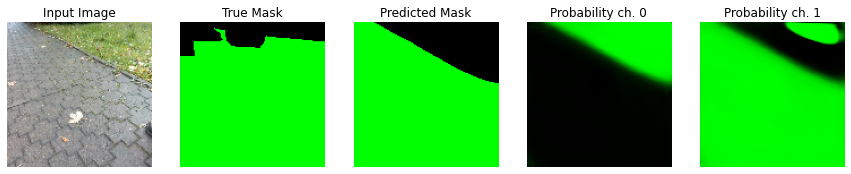

1
1/1 [==============================] - 0s 23ms/step


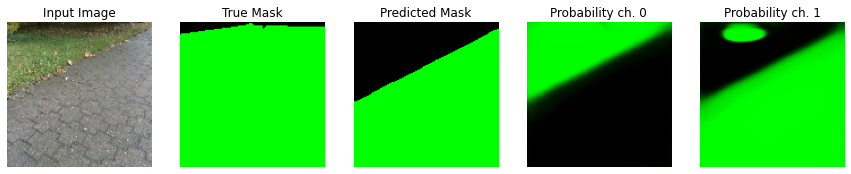

In [ ]:
show_predictions(model, tt, 50)

Trenovani modulu

In [ ]:
#RestoreFromGD(model, resultDir+'/models')
#LoadWeights(model, resultDir+'/models', 'Model61.3_weights_0.9599023461341858.h5' )


t=Trainer([model], resultDir+'/models')
# OPRAVA 9. 9. 2026: druhy argument je VALIDACNI sada (drive tu byla testovaci, takze
# se podle testovaci sady vybiral checkpoint - viz poznamka u Trainer.Train a cela
# s datasety). Testovaci sada se pouzije jedinkrat, o par radku niz.
t.Train(train_dataset, val_dataset, 1000, True)
#tf.saved_model.save(model, "/content/gdrive/saved_models/"+model.name)
t.SavePlot()
t.LoadBest()

t.Disp()
# JEDINE pouziti testovaci sady - az tady, nad uz vybranym modelem
print('presnost na TESTOVACI sade:', ModelAccuracy(model, test_dataset))
show_predictions(model, train, 50)
SaveFrozenGraph(model, resultDir+'/models')
SaveTFLite(model, resultDir+'/models')

copy_tree(resultDir+'/models', '/content/gdrive/My Drive/models')


quantization aware training

In [ ]:
import tensorflow_model_optimization as tfmot

quantize_model = tfmot.quantization.keras.quantize_model

# q_aware stands for for quantization aware.
qmodel = quantize_model(model)

# `quantize_model` requires a recompile.
# OPRAVA 9. 9. 2026: bylo tu from_logits=True nad modelem, ktery KONCI SIGMOIDOU
# (GenericModel20/25 maji activation='sigmoid' na final_conv). from_logits=True znamena
# "vystup jsou logity, dopocitej si softmax sam", takze se pocital softmax NAD SIGMOIDOU -
# dvojita aktivace a jina ztrata, nez se kterou se trenoval nekvantizovany model.
# U modelu z GenericModel27 (softmax na vystupu) je from_logits=False rovnez spravne.
qmodel.compile(optimizer=tf.keras.optimizers.Adam(epsilon=1e-7, learning_rate=0.001), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['sparse_categorical_accuracy'])

qmodel.summary()

qt=Trainer([qmodel], resultDir+'/qmodels')
qt.Train(train1_dataset, val_dataset, 10, True)
qt.SavePlot()
#qt.LoadBest()

qt.Disp()
print('presnost na TESTOVACI sade:', ModelAccuracy(qmodel, test_dataset))
show_predictions(qmodel, train, 50)
SaveFrozenGraph(qmodel, resultDir+'/qmodels')
SaveTFLite(qmodel, resultDir+'/qmodels')

copy_tree(resultDir+'/qmodels', '/content/gdrive/My Drive/qmodels')



0
1/1 [==============================] - 0s 23ms/step


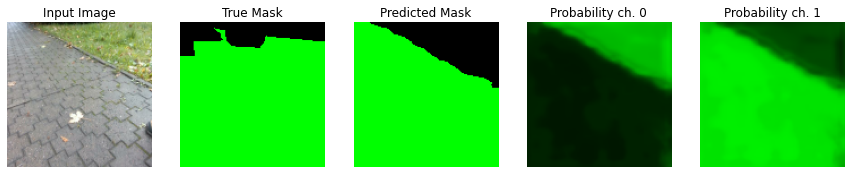

1
1/1 [==============================] - 0s 22ms/step


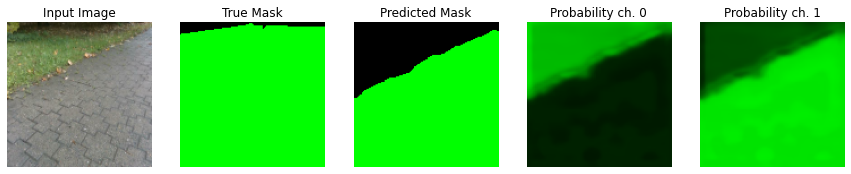

In [ ]:
# ukaze vysledek natrenovani na tt datach, ktere mohu otestovat na Coral
show_predictions(model, tt, 2)
print('kvantizovany model')
for image, mask in tt:
  display([image, mask, create_mask(TFLitePredict(resultDir+'/models/'+model.name+'/'+model.name+'_int8.tflite', image))[0]])
#for image, mask in train.take(10):
#  display([image, mask])

In [ ]:
#RestoreFromGD(model, resultDir+'/models')
#LoadWeights(model, resultDir+'/models', 'Model61.3_weights_0.9599023461341858.h5' )

show_predictions(model, test, 50)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#ModelAccuracy(model, test_dataset)
SaveTFLite(model, resultDir+'/models')


INFO:tensorflow:Assets written to: /tmp/tmpq6ekxerc/assets
INFO:tensorflow:Assets written to: /tmp/tmpavzu0o85/assets


INFO:tensorflow:Assets written to: /tmp/tmpavzu0o85/assets


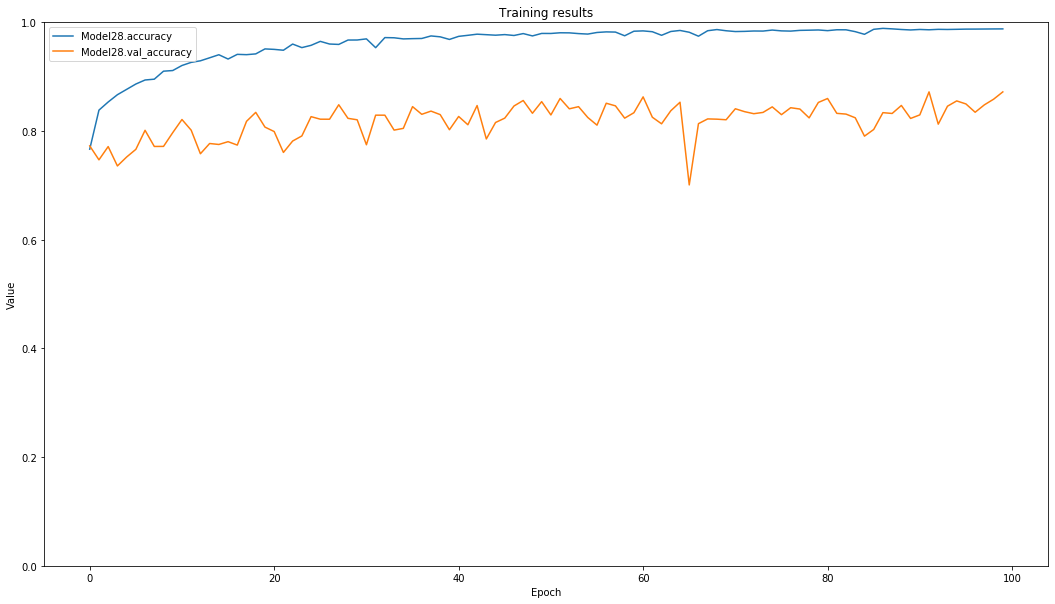

In [ ]:
#model28
t.Disp()

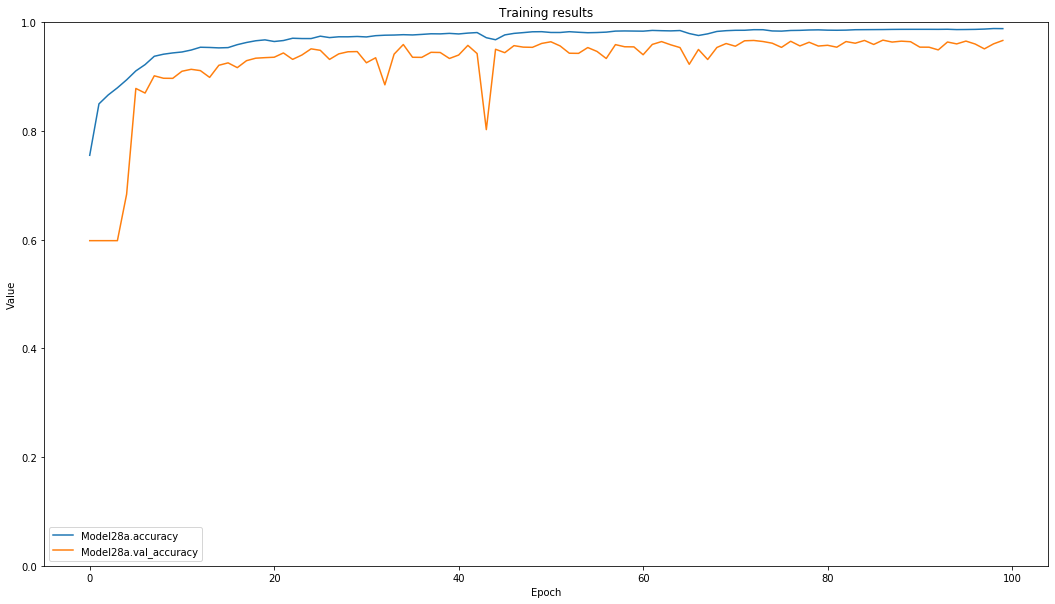

In [ ]:
#model28a
t.Disp()

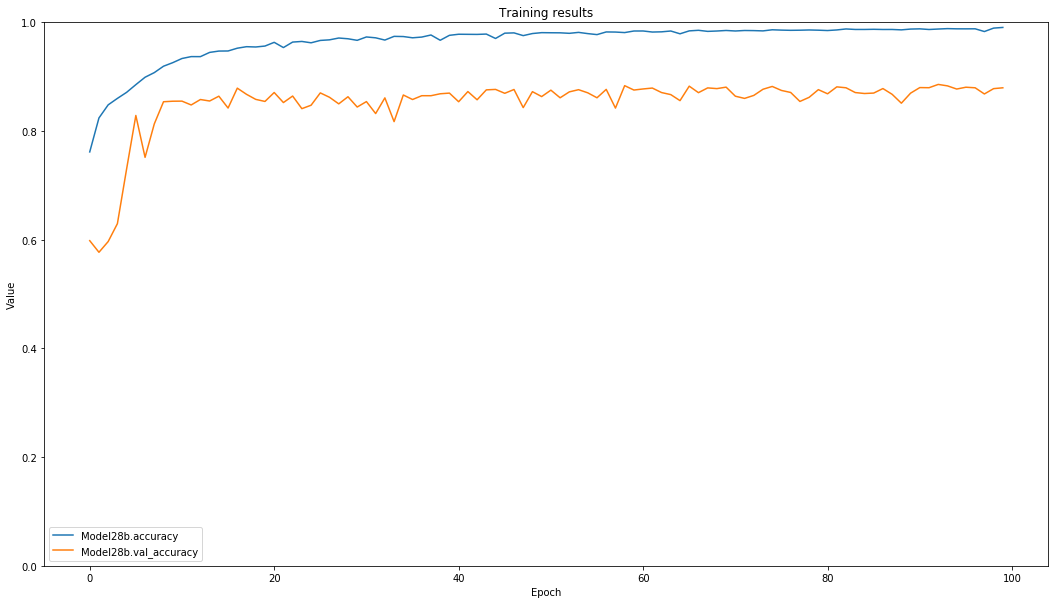

In [ ]:
#model28b
t.Disp()

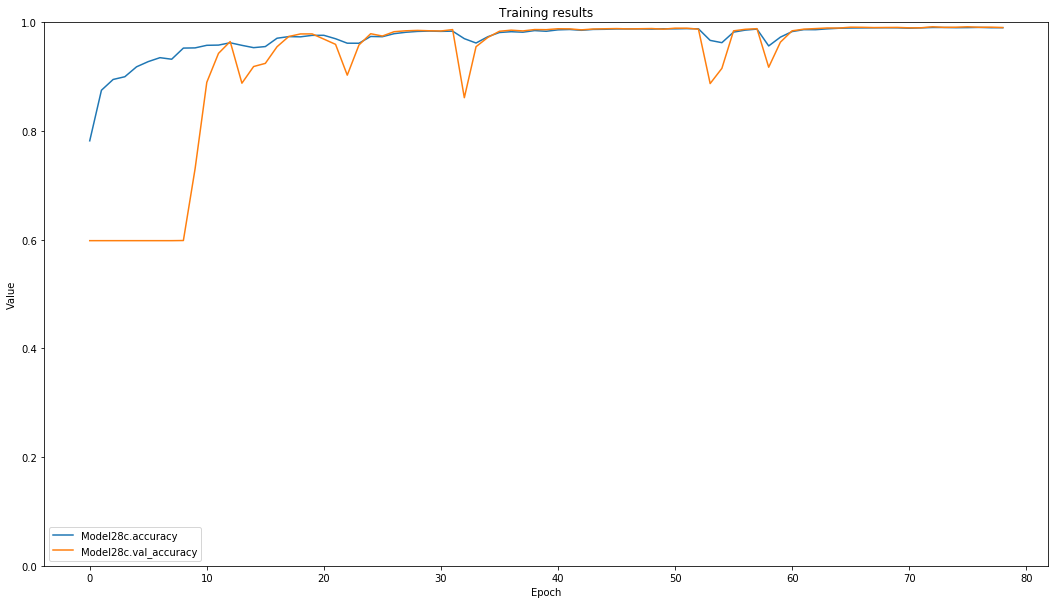

In [ ]:
#model28c
t.Disp()

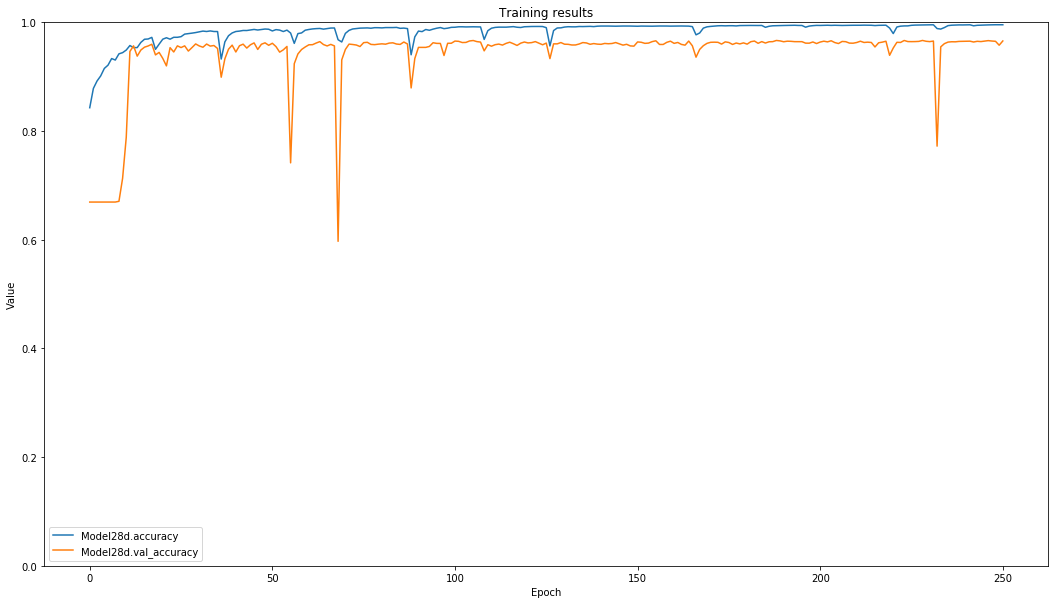

In [ ]:
#model28d
t.Disp()

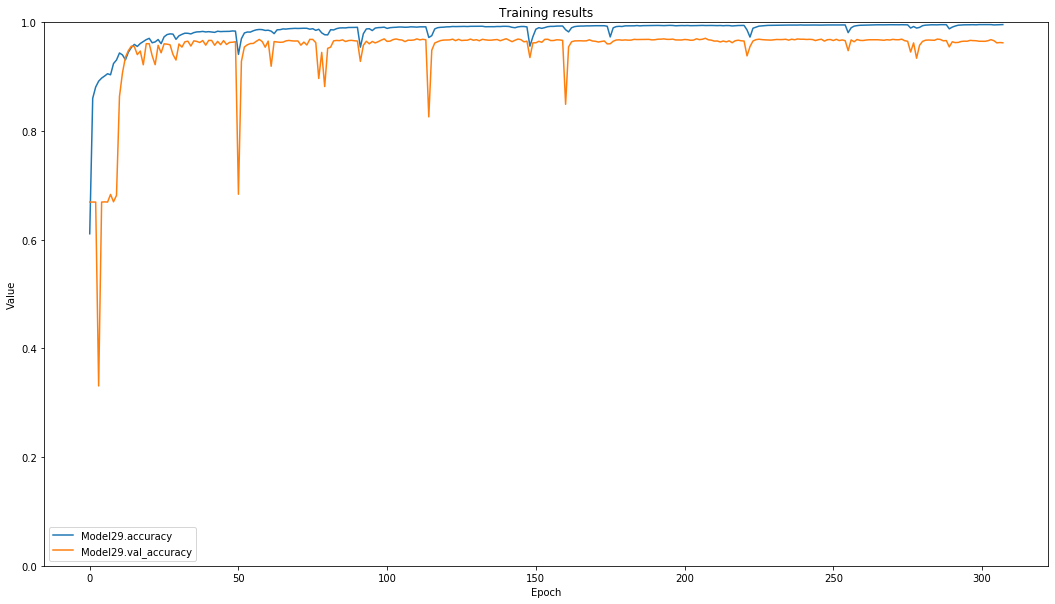

In [ ]:
#model29
t.Disp()

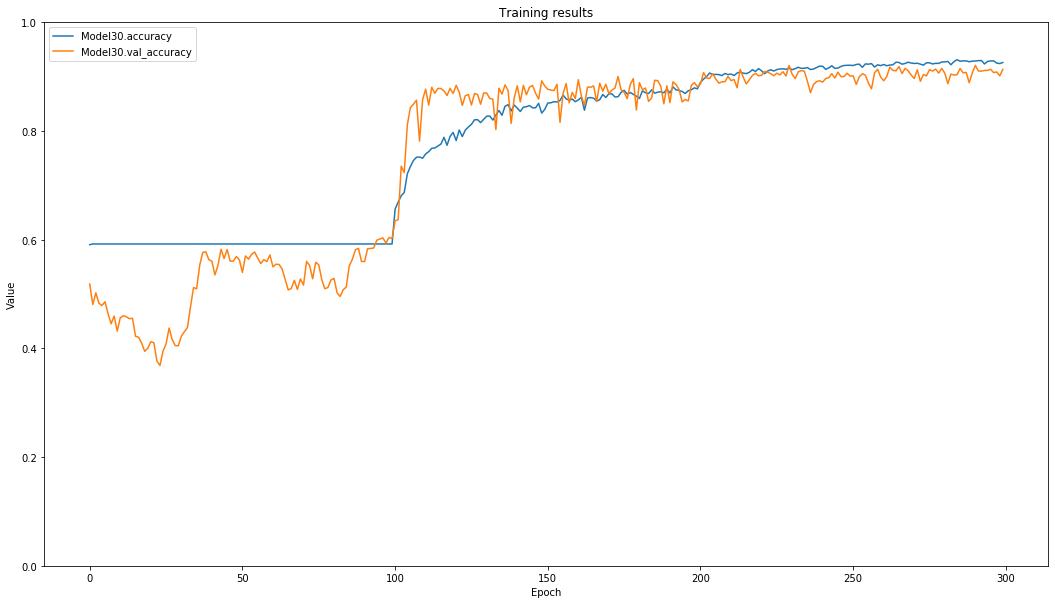

In [ ]:
#model30
t.Disp()

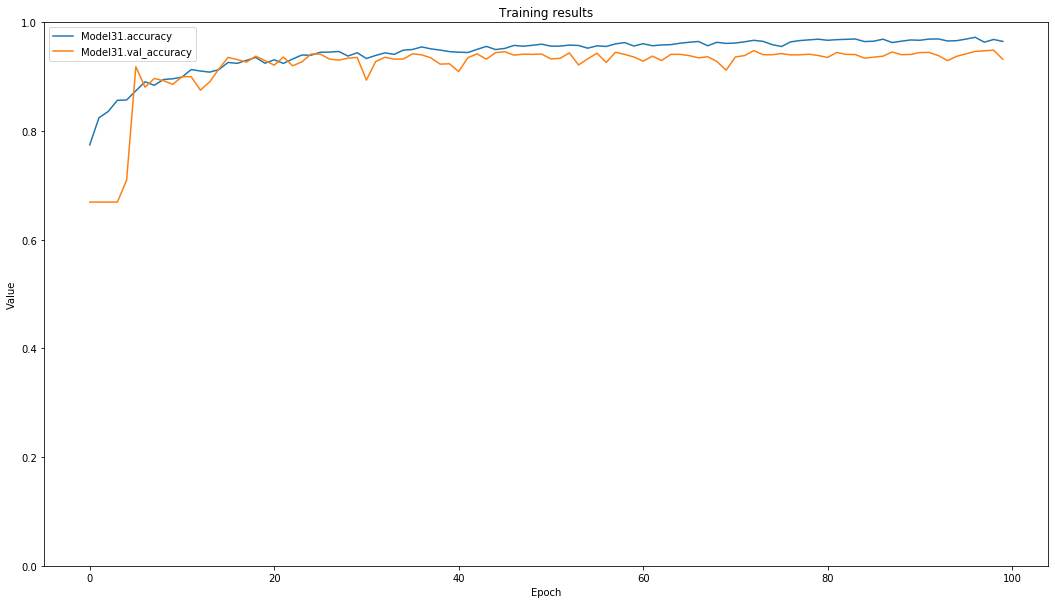

In [ ]:
#model31
t.Disp()

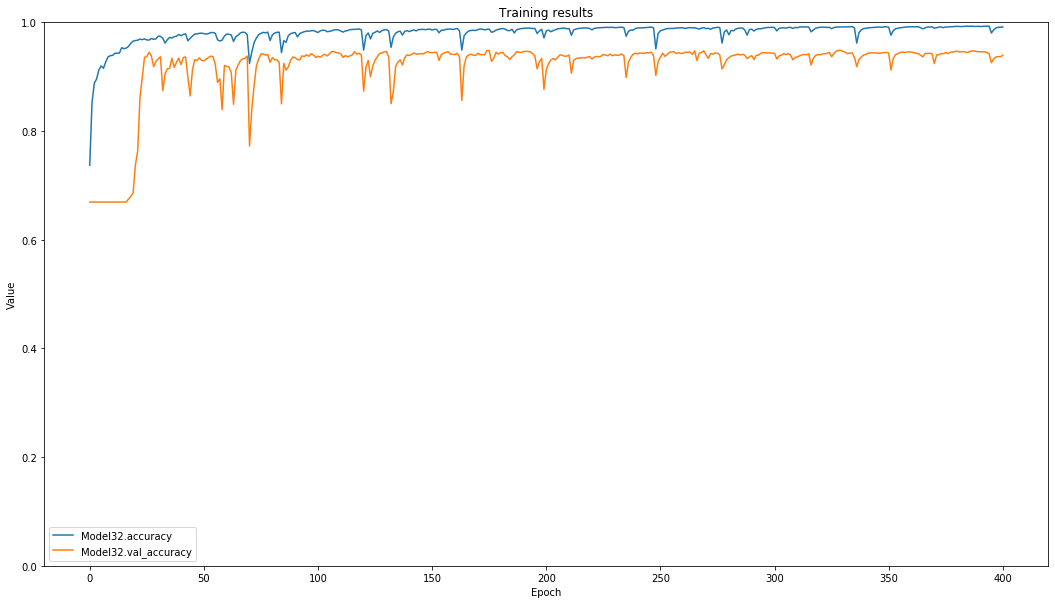

In [ ]:
#model32
t.Disp()

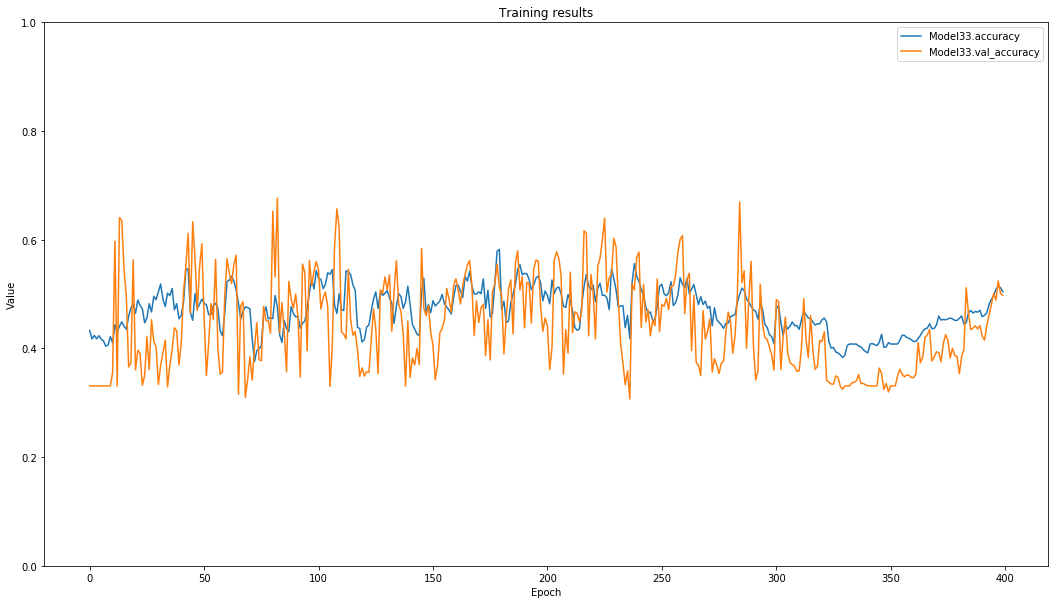

In [ ]:
#model33
t.Disp()

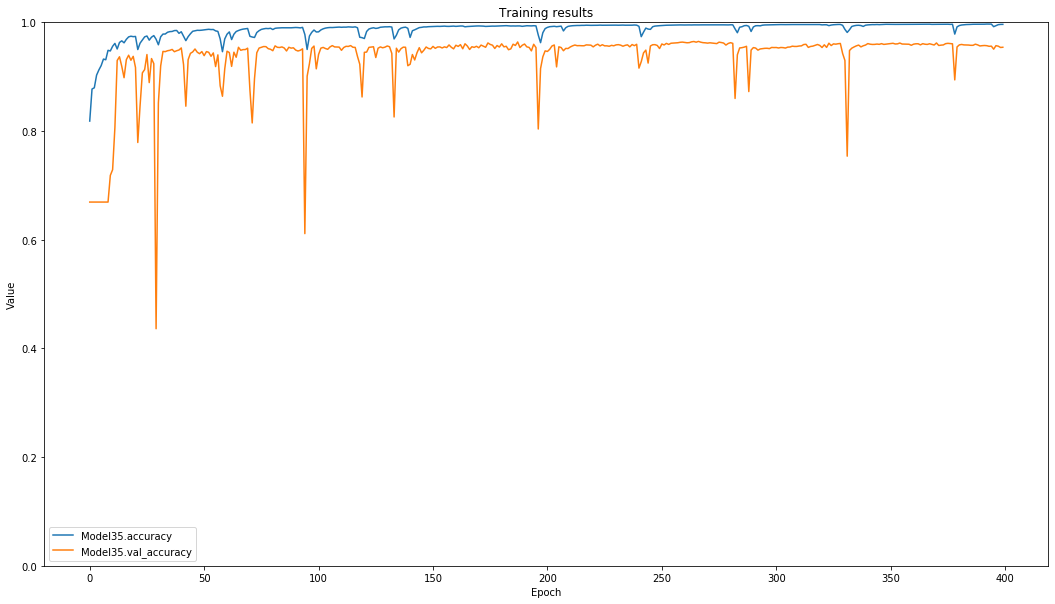

In [ ]:
#model35
t.Disp()

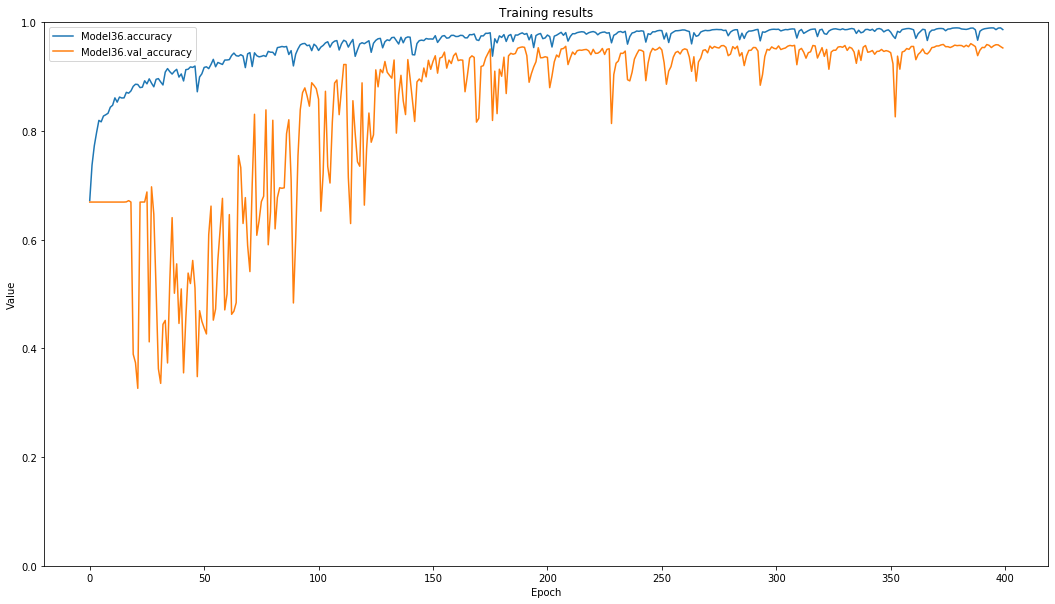

In [ ]:
#model36
t.Disp()

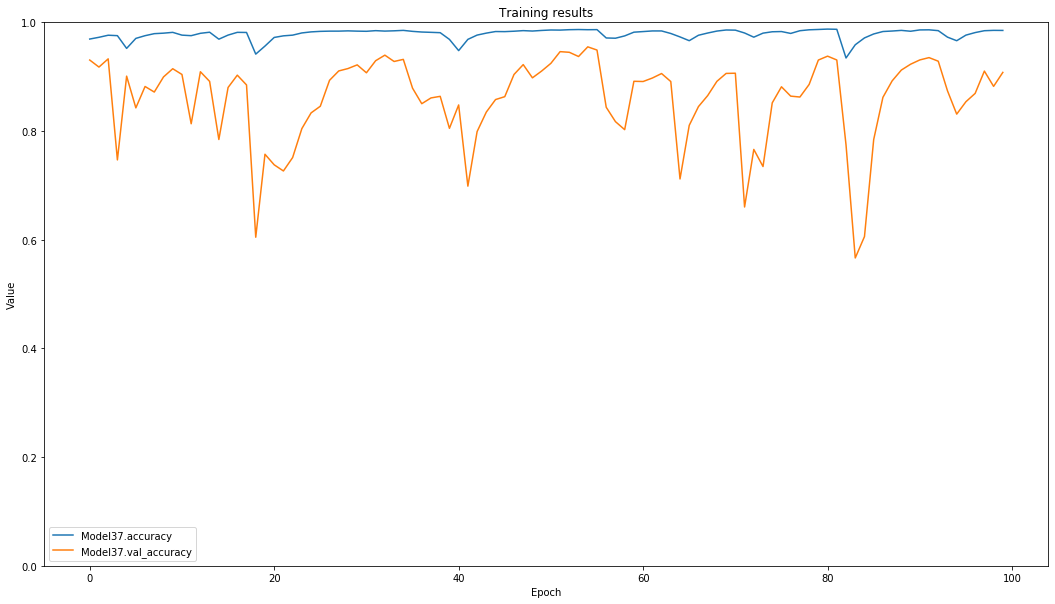

In [ ]:
#model37
t.Disp()

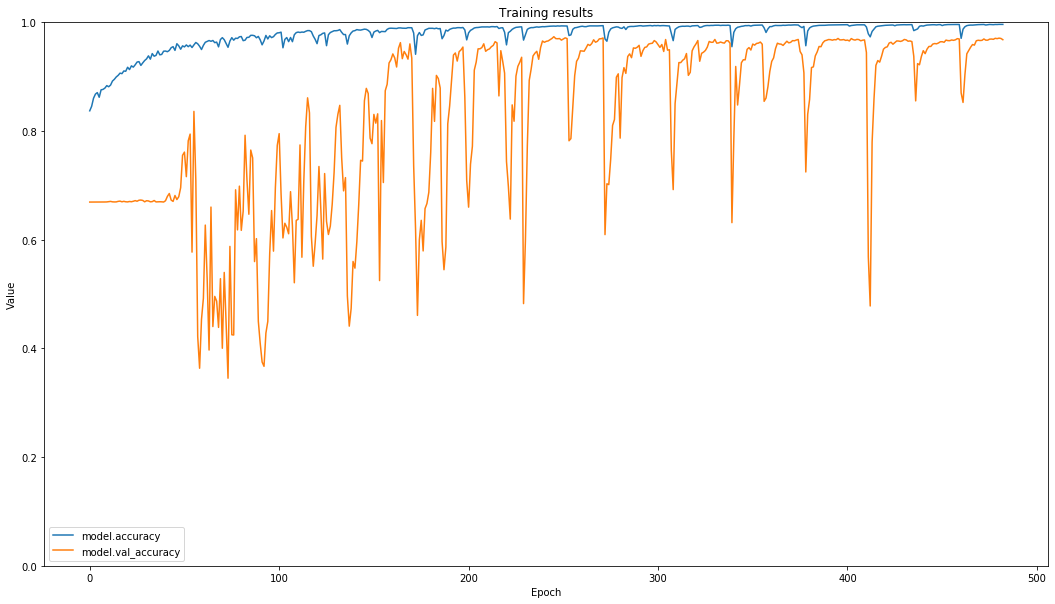

In [ ]:
#model38
t.Disp()

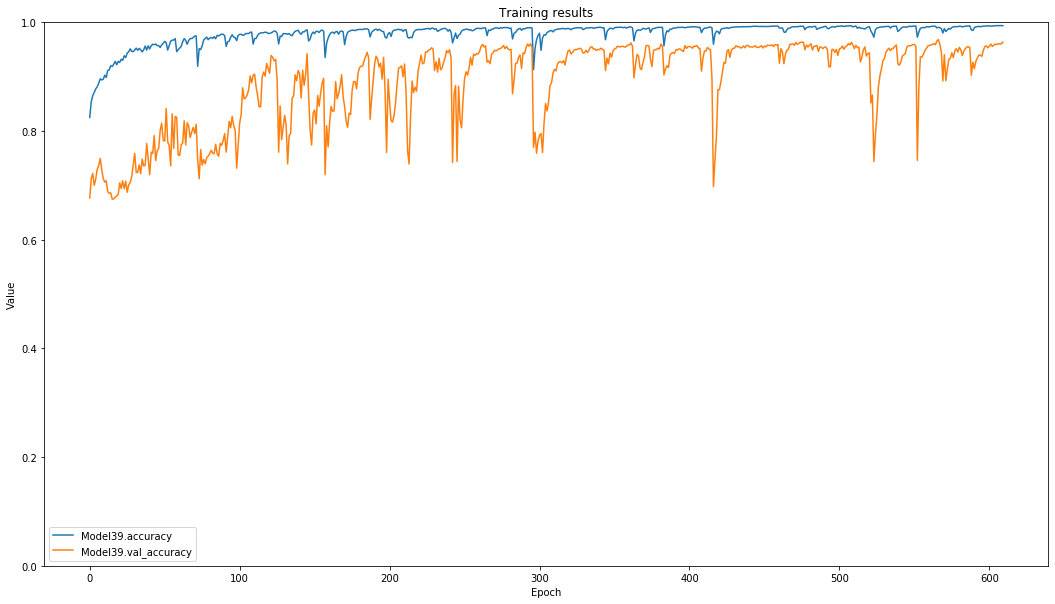

In [ ]:
#model39
t.Disp()

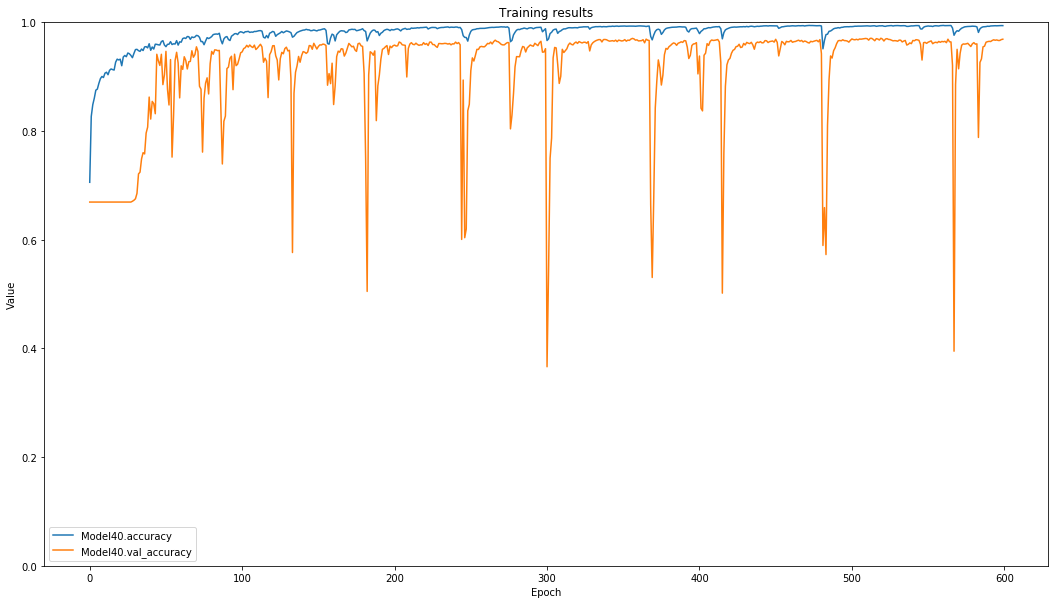

In [ ]:
#model40
t.Disp()

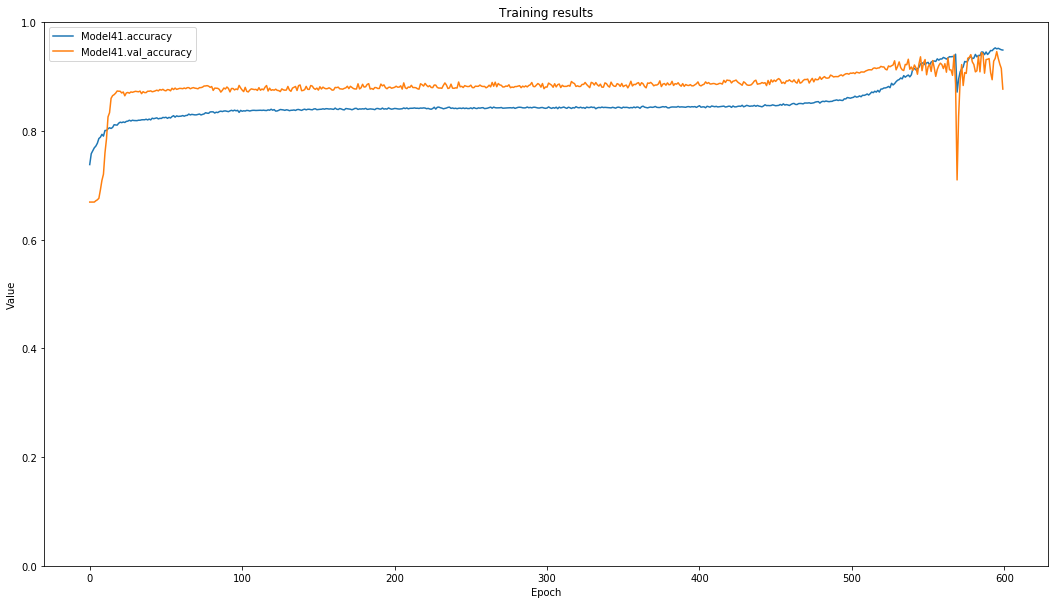

In [ ]:
#model41
t.Disp()

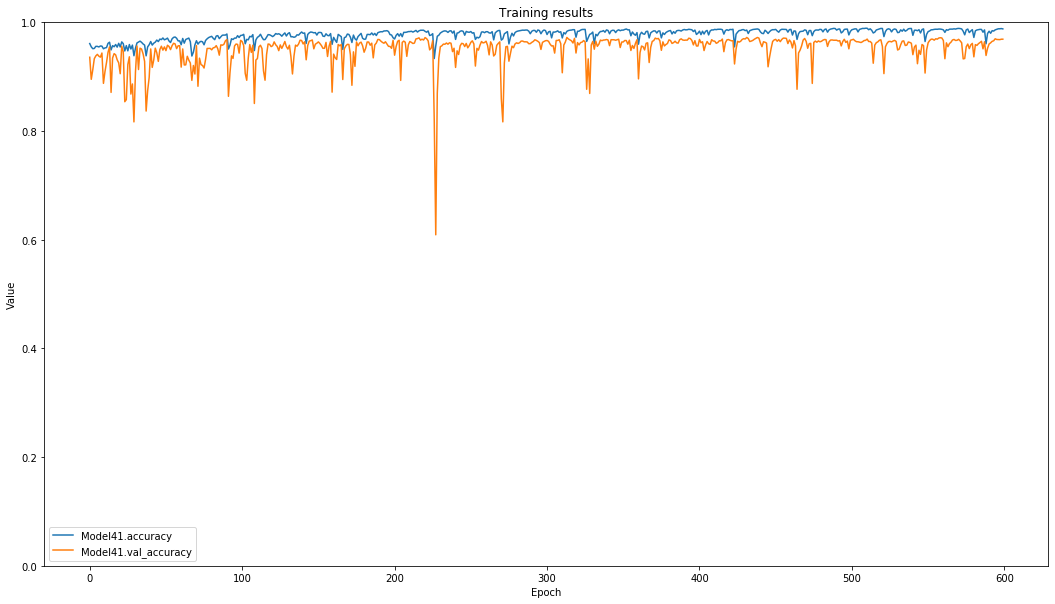

In [ ]:
#model41 pokracovani
t.Disp()

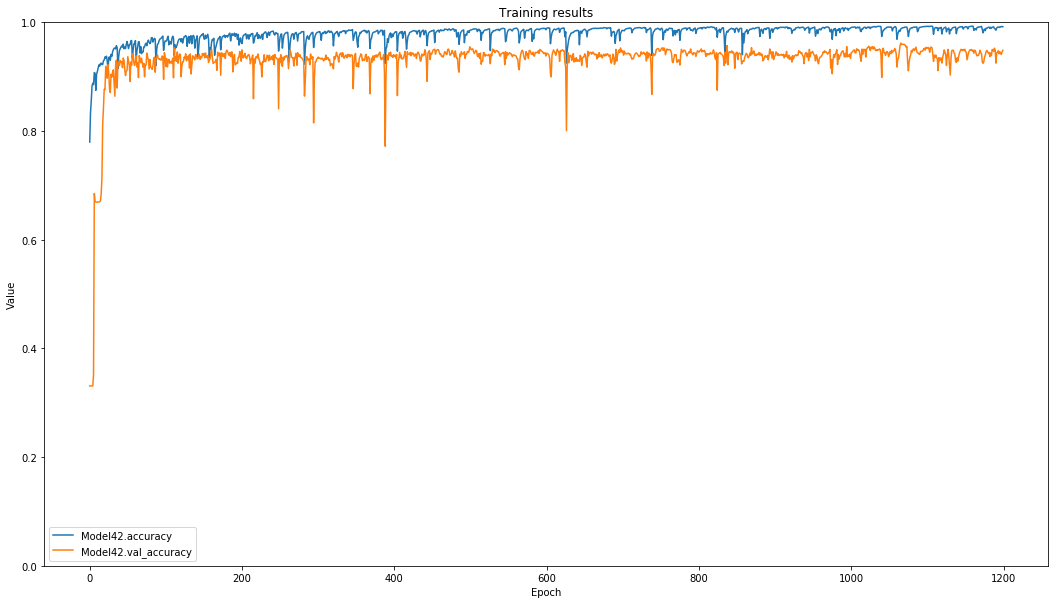

In [ ]:
#model42
t.Disp()

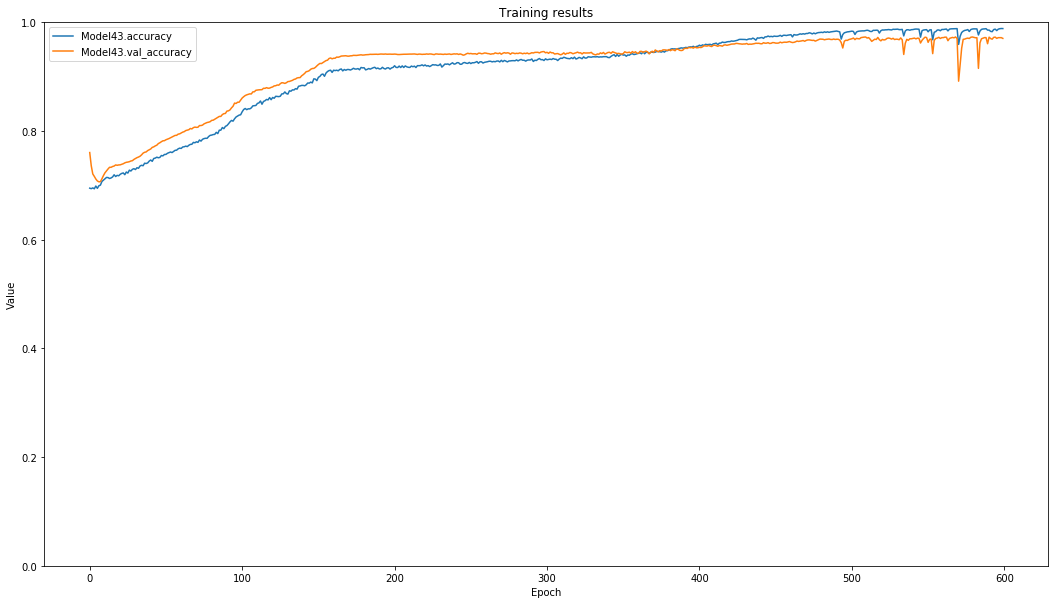

In [ ]:
#model43
t.Disp()

## Make predictions

Let's make some predictions. In the interest of saving time, the number of epochs was kept small, but you may set this higher to achieve more accurate results.

In [ ]:
# OPRAVA 9. 9. 2026: chybel prvni argument (model), takze se za dataset predaval 50.
show_predictions(model, train, 50)

In [ ]:
# OPRAVA 9. 9. 2026: chybel model a CONCAT_STEPS nebyla nikde definovana.
show_predictions(model, test.concatenate(train), 10)

In [ ]:
# ⚠️ MRTVY KOD Z TF1, ZAKOMENTOVANO 9. 9. 2026.
# Tohle nikdy nemohlo bezet: tf.graph_util v TF2 neexistuje (je to tf.compat.v1.graph_util)
# a promenna `sess` se v notebooku nikde nezaklada - TF2 bezi eagerly, zadna session neni.
# Totez, co to melo delat, uz umi SaveFrozenGraph() vys (convert_variables_to_constants_v2).
#
# import tensorflow as tf
# from tensorflow.python.framework import graph_io
# frozen = tf.graph_util.convert_variables_to_constants(sess, sess.graph_def, ["name_of_the_output_node"])
# graph_io.write_graph(frozen, './', 'inference_graph.pb', as_text=False)


## TODO

In [ ]:
!pip install hls4ml

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 KB 26.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 97.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.19.6
    Uninstalling protobuf-3.19.6:
      Successfully uninstalled protobuf-3.19.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.11.0 requires protobuf<3.20,>=3.9.2, but you have protobuf 3.20.3 which is incompatible.


In [ ]:
import hls4ml

#hls4ml.utils.fetch_example_list()

config = hls4ml.utils.fetch_example_model('KERAS_3layer.json')

print(config) #You can print it to see some default parameters

#Convert it to a hls project
hls_model = hls4ml.converters.keras_to_hls(config)

hls_model.write()

{'OutputDir': 'my-hls-test', 'ProjectName': 'myproject', 'Backend': 'Vivado', 'XilinxPart': 'xcku115-flvb2104-2-i', 'Board': None, 'ClockPeriod': 5, 'IOType': 'io_parallel', 'HLSConfig': {'Model': {'Precision': 'ap_fixed<16,6>', 'ReuseFactor': '1'}}, 'KerasJson': 'KERAS_3layer.json', 'KerasH5': 'KERAS_3layer_weights.h5'}
Interpreting Model
Topology:
Layer name: input_1, layer type: InputLayer, input shapes: [[None, 16]], output shape: [None, 16]
Layer name: fc1_relu, layer type: Dense, input shapes: [[None, 16]], output shape: [None, 64]
Layer name: fc2_relu, layer type: Dense, input shapes: [[None, 64]], output shape: [None, 32]
Layer name: fc3_relu, layer type: Dense, input shapes: [[None, 32]], output shape: [None, 32]
Layer name: output_softmax, layer type: Dense, input shapes: [[None, 32]], output shape: [None, 5]
Creating HLS model
Writing HLS project
Done


In [ ]:
import hls4ml
import tensorflow.keras as keras

m=GenericModel25('Model96.1', (shape[0], shape[1], 3), 2, 1, 0.99, 0.2, 'float32', [[128, 128, 128], [128, 128, 128]], [[128, 128, 128], [128, 128, 128]], [False, False], [], 9, 4)
m.load_weights('/content/gdrive/MyDrive/models/Model96.1/Model96.1_0.965740978717804.h5')

clear_output(wait=True)

depthRF=2 #1327104
projectExpandRF=2 #16384

config={'Model': {'Precision': 'ap_fixed<16,6>', 'ReuseFactor': 1, 'Strategy': 'Resource'}}
config['LayerName']={
    'encoder_0_0_expand': {'ReuseFactor': 96},
    'final_conv': {'ReuseFactor': 64},

    'encoder_0_0_expand': {'ReuseFactor': 96},

    'encoder_0_0_depth': {'ReuseFactor': depthRF},
    'encoder_0_1_depth': {'ReuseFactor': depthRF},
    'encoder_0_2_depth': {'ReuseFactor': depthRF},
    'encoder_1_0_depth': {'ReuseFactor': depthRF},
    'encoder_1_1_depth': {'ReuseFactor': depthRF},
    'encoder_1_2_depth': {'ReuseFactor': depthRF},

    'encoder_0_0_project': {'ReuseFactor': projectExpandRF},
    'encoder_0_1_project': {'ReuseFactor': projectExpandRF},
    'encoder_0_1_expand': {'ReuseFactor': projectExpandRF},
    'encoder_0_2_project': {'ReuseFactor': projectExpandRF},
    'encoder_0_2_expand': {'ReuseFactor': projectExpandRF},
    'encoder_1_0_project': {'ReuseFactor': projectExpandRF},
    'encoder_1_0_expand': {'ReuseFactor': projectExpandRF},
    'encoder_1_1_project': {'ReuseFactor': projectExpandRF},
    'encoder_1_1_expand': {'ReuseFactor': projectExpandRF},
    'encoder_1_2_project': {'ReuseFactor': projectExpandRF},
    'encoder_1_2_expand': {'ReuseFactor': projectExpandRF},

    'decoder_0_0_depth': {'ReuseFactor': depthRF},
    'decoder_0_1_depth': {'ReuseFactor': depthRF},
    'decoder_0_2_depth': {'ReuseFactor': depthRF},
    'decoder_1_0_depth': {'ReuseFactor': depthRF},
    'decoder_1_1_depth': {'ReuseFactor': depthRF},
    'decoder_1_2_depth': {'ReuseFactor': depthRF},

    'decoder_0_0_project': {'ReuseFactor': projectExpandRF},
    'decoder_0_0_expand': {'ReuseFactor': projectExpandRF},
    'decoder_0_1_project': {'ReuseFactor': projectExpandRF},
    'decoder_0_1_expand': {'ReuseFactor': projectExpandRF},
    'decoder_0_2_project': {'ReuseFactor': projectExpandRF},
    'decoder_0_2_expand': {'ReuseFactor': projectExpandRF},
    'decoder_1_0_project': {'ReuseFactor': projectExpandRF},
    'decoder_1_0_expand': {'ReuseFactor': projectExpandRF},
    'decoder_1_1_project': {'ReuseFactor': projectExpandRF},
    'decoder_1_1_expand': {'ReuseFactor': projectExpandRF},
    'decoder_1_2_project': {'ReuseFactor': projectExpandRF},
    'decoder_1_2_expand': {'ReuseFactor': projectExpandRF}

    }

print(config)

hls_model = hls4ml.converters.convert_from_keras_model(m,
                                                       hls_config=config,
                                                       output_dir='hls/Model96',
                                                       io_type='io_stream',
                                                       part='xck26-sfvc784-2LV-c')
hls_model.write()


{'Model': {'Precision': 'ap_fixed<16,6>', 'ReuseFactor': 1, 'Strategy': 'Resource'}, 'LayerName': {'encoder_0_0_expand': {'ReuseFactor': 96}, 'final_conv': {'ReuseFactor': 64}, 'encoder_0_0_depth': {'ReuseFactor': 2}, 'encoder_0_1_depth': {'ReuseFactor': 2}, 'encoder_0_2_depth': {'ReuseFactor': 2}, 'encoder_1_0_depth': {'ReuseFactor': 2}, 'encoder_1_1_depth': {'ReuseFactor': 2}, 'encoder_1_2_depth': {'ReuseFactor': 2}, 'encoder_0_0_project': {'ReuseFactor': 2}, 'encoder_0_1_project': {'ReuseFactor': 2}, 'encoder_0_1_expand': {'ReuseFactor': 2}, 'encoder_0_2_project': {'ReuseFactor': 2}, 'encoder_0_2_expand': {'ReuseFactor': 2}, 'encoder_1_0_project': {'ReuseFactor': 2}, 'encoder_1_0_expand': {'ReuseFactor': 2}, 'encoder_1_1_project': {'ReuseFactor': 2}, 'encoder_1_1_expand': {'ReuseFactor': 2}, 'encoder_1_2_project': {'ReuseFactor': 2}, 'encoder_1_2_expand': {'ReuseFactor': 2}, 'decoder_0_0_depth': {'ReuseFactor': 2}, 'decoder_0_1_depth': {'ReuseFactor': 2}, 'decoder_0_2_depth': {'Reus

IndexError: ignored

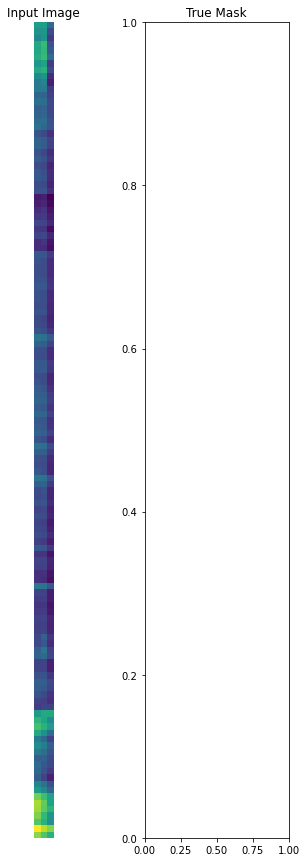

In [ ]:
#hls_model.compile()
for image, mask in tt.take(1):
  display([image[0], mask[0], image[0], mask[0], image[0]])
#X_test = np.ascontiguousarray(X_test)
#y_hls = hls_model.predict(X_test)